In [1]:
pip install statsmodels lightgbm xgboost prophet scikit-learn shap optuna

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Mô hình dự báo doanh thu

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
import json
import pickle
from pathlib import Path
from sklearn.metrics import r2_score
import shap
import optuna
import random
import os

optuna.logging.set_verbosity(optuna.logging.WARNING) 
warnings.filterwarnings("ignore")

### Giai đoạn 1: EDA và phân tích chuỗi thời gian

In [3]:
# CẤU HÌNH

DATA_PATH   = "dataset/sales.csv"          # Đường dẫn file CSV đầu vào
OUTPUT_DIR  = Path("output")       # Thư mục lưu kết quả
OUTPUT_DIR.mkdir(exist_ok=True)
MODEL_DIR  = OUTPUT_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
SUBMIT_DIR  = OUTPUT_DIR / "submission"
SUBMIT_DIR.mkdir(parents=True, exist_ok=True)
 
TRAIN_END   = "2020-12-31"
VAL_START   = "2021-01-01"
VAL_END     = "2021-12-31"
TEST_START  = "2022-01-01"
TEST_END    = "2022-12-31"

IQR_MULTIPLIER = 1.5   # Hệ số IQR tiêu chuẩn
 
TARGET_COL    = "Revenue"
LAMBDA_DECAY  = 2.0      # Hệ số exponential decay cho sample_weight
RANDOM_STATE  = 42
 
# Walk-forward: số bước dự báo mỗi fold (30 ngày = ~1 tháng)
WF_STEP_DAYS  = 30
WF_N_FOLDS    = 8        # Tổng ~8 tháng đầu validation để chọn mô hình
 
def set_global_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)

set_global_seed(RANDOM_STATE)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "font.size":        10,
})

In [4]:
# ─────────────────────────────────────────────
# 1. TẢI VÀ KIỂM TRA DỮ LIỆU
# ─────────────────────────────────────────────

df = pd.read_csv(DATA_PATH, parse_dates=["Date"])

# Sắp xếp theo thời gian — bắt buộc với time series
df = df.sort_values("Date").reset_index(drop=True)

print(f"\n[INFO] Kích thước dataset     : {df.shape[0]:,} dòng × {df.shape[1]} cột")
print(f"[INFO] Khoảng thời gian       : {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"[INFO] Số ngày giao dịch      : {df['Date'].nunique():,}")
print(f"[INFO] Kiểu dữ liệu:\n{df.dtypes}")

# ── 1a. Missing values ──────────────────────
missing = df.isnull().sum()
print(f"\n[MISSING VALUES]\n{missing}")
if missing.sum() > 0:
    print("  ⚠ Phát hiện missing — cần xử lý trước feature engineering!")
else:
    print("  ✓ Không có missing values.")

# ── 1b. Kiểm tra trùng lặp ─────────────────
dup_dates = df.duplicated(subset="Date").sum()
print(f"\n[DUPLICATE DATES] : {dup_dates}")

# ── 1c. Thống kê mô tả ─────────────────────
print("\n[THỐNG KÊ MÔ TẢ]")
desc = df[["Revenue", "COGS"]].describe().round(2)
print(desc.to_string())

# ── 1d. Kiểm tra giá trị âm / bằng 0 ───────
neg_rev  = (df["Revenue"] <= 0).sum()
neg_cogs = (df["COGS"] <= 0).sum()
print(f"\n[KIỂM TRA GIÁ TRỊ]\n  Revenue ≤ 0 : {neg_rev} dòng\n  COGS    ≤ 0 : {neg_cogs} dòng")

# ── 1e. Tính COGS margin ────────────────────
df["COGS_margin"] = df["COGS"] / df["Revenue"]
avg_margin = df["COGS_margin"].mean()
print(f"\n[COGS MARGIN] Trung bình: {avg_margin:.3f} ({avg_margin*100:.1f}%)")


[INFO] Kích thước dataset     : 3,833 dòng × 3 cột
[INFO] Khoảng thời gian       : 2012-07-04 → 2022-12-31
[INFO] Số ngày giao dịch      : 3,833
[INFO] Kiểu dữ liệu:
Date       datetime64[ns]
Revenue           float64
COGS              float64
dtype: object

[MISSING VALUES]
Date       0
Revenue    0
COGS       0
dtype: int64
  ✓ Không có missing values.

[DUPLICATE DATES] : 0

[THỐNG KÊ MÔ TẢ]
           Revenue         COGS
count      3833.00      3833.00
mean    4286584.03   3695134.49
std     2624840.20   2219788.77
min      279813.94    236576.31
25%     2471088.82   2150580.23
50%     3647303.90   3161112.99
75%     5350877.20   4637293.92
max    20905271.35  16535857.67

[KIỂM TRA GIÁ TRỊ]
  Revenue ≤ 0 : 0 dòng
  COGS    ≤ 0 : 0 dòng

[COGS MARGIN] Trung bình: 0.875 (87.5%)


In [5]:
# ─────────────────────────────────────────────
# 2. PHÂN TÍCH VÀ XỬ LÝ CÚ SỐC COVID-19
# ─────────────────────────────────────────────

df_clean   = df.copy()
df_clean["Year"] = df_clean["Date"].dt.year

# Revenue trung bình theo năm
yearly_avg = df_clean.groupby("Year")["Revenue"].mean()
print("\n  Revenue TB/ngày theo năm:")
for yr, avg in yearly_avg.items():
    tag = " ← Bắt đầu chịu tác động dịch?" if yr == 2020 else ""
    print(f"    {yr}: {avg:>12,.0f}{tag}")
 
# Kiểm tra thống kê sự thay đổi tổng quan trước/sau 2020 (EDA)
pre_break  = df_clean[df_clean["Year"] <= 2019]["Revenue"]
post_break = df_clean[df_clean["Year"] >= 2020]["Revenue"]
pct_change = (post_break.mean() - pre_break.mean()) / pre_break.mean() * 100
 
print(f"\n  TB Revenue trước 2020  : {pre_break.mean():>12,.0f}")
print(f"  TB Revenue từ 2020+    : {post_break.mean():>12,.0f}")
print(f"  Thay đổi tổng quan     : {pct_change:+.1f}%")
 
# --- TẠO BIẾN CÚ SỐC PHÂN RÃ (COVID_DECAY_SHOCK) ---

# 1. Xác định ngày bắt đầu tính cú sốc
COVID_START_DATE = pd.to_datetime("2019-01-01")

# 2. Tính số ngày kể từ t0. Hàm clip(lower=0) đảm bảo thời gian trước dịch sẽ = 0
days_since_covid = (df_clean["Date"] - COVID_START_DATE).dt.days
days_since_covid = days_since_covid.clip(lower=0)

# 3. Cấu hình tốc độ phân rã (Lambda)
# Xem xét nếu muốn thay đổi
LAMBDA_DECAY_RATE = 0.004

# 4. Áp dụng công thức: max(0, e^(-lambda * (t - t0)))
df_clean["Covid_Decay_Shock"] = np.where(
    df_clean["Date"] < COVID_START_DATE,
    0.0,
    np.exp(-LAMBDA_DECAY_RATE * days_since_covid)
)

print(f"    - Ngày bắt đầu (t0)      : {COVID_START_DATE.date()}")
print(f"    - Tốc độ phân rã (lambda): {LAMBDA_DECAY_RATE}")

# --- KIỂM TRA TRỰC QUAN MỘT VÀI MỐC THỜI GIAN ---
print("\n  [MÔ PHỎNG] Giá trị Covid_Decay_Shock qua các mốc thời gian:")
check_dates = ["2019-12-31", "2020-01-01", "2020-06-30", "2020-12-31", "2021-12-31", "2022-12-31", "2023-12-31"]

for d_str in check_dates:
    d = pd.to_datetime(d_str)
    delta_days = (d - COVID_START_DATE).days
    
    if delta_days < 0:
        val = 0.0
    else:
        val = np.exp(-LAMBDA_DECAY_RATE * delta_days)
        
    print(f"    {d_str}: {val:.4f}")


  Revenue TB/ngày theo năm:
    2012:    4,096,673
    2013:    4,540,190
    2014:    5,128,345
    2015:    5,177,901
    2016:    5,750,384
    2017:    5,236,067
    2018:    5,068,829
    2019:    3,114,524
    2020:    2,881,181 ← Bắt đầu chịu tác động dịch?
    2021:    2,857,643
    2022:    3,204,791

  TB Revenue trước 2020  :    4,809,344
  TB Revenue từ 2020+    :    2,981,114
  Thay đổi tổng quan     : -38.0%
    - Ngày bắt đầu (t0)      : 2019-01-01
    - Tốc độ phân rã (lambda): 0.004

  [MÔ PHỎNG] Giá trị Covid_Decay_Shock qua các mốc thời gian:
    2019-12-31: 0.2332
    2020-01-01: 0.2322
    2020-06-30: 0.1126
    2020-12-31: 0.0539
    2021-12-31: 0.0125
    2022-12-31: 0.0029
    2023-12-31: 0.0007


In [6]:
# ─────────────────────────────────────────────
# 3. KIỂM TRA TÍNH DỪNG (ADF)
# ─────────────────────────────────────────────

try:
    from statsmodels.tsa.stattools import adfuller
 
    train_rev = df_clean[df_clean["Date"] <= TRAIN_END]["Revenue"]
 
    # ADF trên chuỗi gốc
    adf0 = adfuller(train_rev.dropna(), autolag="AIC")
    print(f"\n  [Chuỗi gốc] ADF={adf0[0]:.4f}, p={adf0[1]:.4f}", end=" ")
    print("✓ Dừng" if adf0[1] < 0.05 else "⚠ Không dừng → cần differencing")
 
    # ADF trên chuỗi differencing bậc 1
    rev_diff1 = train_rev.diff().dropna()
    adf1 = adfuller(rev_diff1, autolag="AIC")
    print(f"  [Diff bậc 1] ADF={adf1[0]:.4f}, p={adf1[1]:.4f}", end=" ")
    print("✓ Dừng sau diff(1)" if adf1[1] < 0.05 else "⚠ Vẫn không dừng")
 
    print("\n  → Ghi chú cho Giai đoạn 2:")
    if adf1[1] < 0.05:
        print("    - Với ML models (XGBoost, LightGBM): thêm diff(1) làm feature")
    else:
        print("    - Xem xét seasonal differencing hoặc log transform")
 
except ImportError:
    print("\n  [INFO] pip install statsmodels để chạy ADF test")


  [Chuỗi gốc] ADF=-2.1264, p=0.2340 ⚠ Không dừng → cần differencing
  [Diff bậc 1] ADF=-21.0740, p=0.0000 ✓ Dừng sau diff(1)

  → Ghi chú cho Giai đoạn 2:
    - Với ML models (XGBoost, LightGBM): thêm diff(1) làm feature


In [7]:
# ─────────────────────────────────────────────
# 4. CHIA TẬP DỮ LIỆU
# ─────────────────────────────────────────────
 
train = df_clean[df_clean["Date"] <= TRAIN_END].copy()
val   = df_clean[(df_clean["Date"] >= VAL_START) & (df_clean["Date"] <= VAL_END)].copy()
test  = df_clean[(df_clean["Date"] >= TEST_START) & (df_clean["Date"] <= TEST_END)].copy()
 
assert train["Date"].max() < pd.Timestamp(VAL_START),  "LEAK: Train → Validation!"
assert val["Date"].max()   < pd.Timestamp(TEST_START), "LEAK: Validation → Test!"
 
total_days = len(df_clean)
for name, split in [("Train", train), ("Validation", val), ("Test nội bộ", test)]:
    pct = len(split) / total_days * 100
    print(f"\n  [{name}]")
    print(f"    Số ngày       : {len(split):>6,}  ({pct:.1f}%)")
    print(f"    Từ → Đến      : {split['Date'].min().date()} → {split['Date'].max().date()}")
    print(f"    Revenue TB/ngày: {split['Revenue'].mean():>10,.0f}")

 
# ─────────────────────────────────────────────
# 5. LƯU FILE
# ─────────────────────────────────────────────
print("\n[LƯU FILE]")
files = {
    "train.csv"           : train,
    "val.csv"             : val,
    "test_internal.csv"   : test,
    "full_daily_clean.csv": df_clean,
}
for fname, split in files.items():
    path = OUTPUT_DIR / fname
    # Bỏ cột trung gian trước khi lưu
    cols_to_drop = [c for c in ["YearMonth"] if c in split.columns]
    split.drop(columns=cols_to_drop).to_csv(path, index=False)
    print(f"  ✓ {path}  ({len(split):,} dòng)")


  [Train]
    Số ngày       :  3,103  (81.0%)
    Từ → Đến      : 2012-07-04 → 2020-12-31
    Revenue TB/ngày:  4,581,917

  [Validation]
    Số ngày       :    365  (9.5%)
    Từ → Đến      : 2021-01-01 → 2021-12-31
    Revenue TB/ngày:  2,857,643

  [Test nội bộ]
    Số ngày       :    365  (9.5%)
    Từ → Đến      : 2022-01-01 → 2022-12-31
    Revenue TB/ngày:  3,204,791

[LƯU FILE]
  ✓ output\train.csv  (3,103 dòng)
  ✓ output\val.csv  (365 dòng)
  ✓ output\test_internal.csv  (365 dòng)
  ✓ output\full_daily_clean.csv  (3,833 dòng)


### Giai đoạn 2: Feature Engineering 

In [8]:
# ─────────────────────────────────────────────
# TẢI DỮ LIỆU TỪ GIAI ĐOẠN 1
# ─────────────────────────────────────────────

train = pd.read_csv(OUTPUT_DIR / "train.csv",         parse_dates=["Date"])
val   = pd.read_csv(OUTPUT_DIR / "val.csv",           parse_dates=["Date"])
test  = pd.read_csv(OUTPUT_DIR / "test_internal.csv", parse_dates=["Date"])

# Ghép toàn bộ để tính lag/rolling liên tục (tránh mất ngữ cảnh ở ranh giới)
# Sau khi tính xong sẽ tách lại theo mask thời gian
full = pd.concat([train, val, test], ignore_index=True).sort_values("Date").reset_index(drop=True)
 
print(f"\n  Train  : {len(train):,} ngày  ({train['Date'].min().date()} → {train['Date'].max().date()})")
print(f"  Val    : {len(val):,} ngày  ({val['Date'].min().date()} → {val['Date'].max().date()})")
print(f"  Test   : {len(test):,} ngày  ({test['Date'].min().date()} → {test['Date'].max().date()})")
print(f"  Full   : {len(full):,} ngày")
 



  Train  : 3,103 ngày  (2012-07-04 → 2020-12-31)
  Val    : 365 ngày  (2021-01-01 → 2021-12-31)
  Test   : 365 ngày  (2022-01-01 → 2022-12-31)
  Full   : 3,833 ngày


In [9]:
# ─────────────────────────────────────────────
# REINDEX 
# ─────────────────────────────────────────────
 
full = full.set_index("Date")
full_range = pd.date_range(full.index.min(), full.index.max(), freq="D")
missing_before = full_range.difference(full.index)
 
if len(missing_before) > 0:
    full = full.reindex(full_range)
    # Forward fill: dùng giá trị ngày trước đó cho ngày bị thiếu
    full[["Revenue", "COGS"]] = full[["Revenue", "COGS"]].ffill()
    # Tính lại COGS_margin sau fill
    full["COGS_margin"] = full["COGS"] / full["Revenue"]
    # Fill các cột binary với mode (0 hoặc 1)
    for col in ["Covid_Decay_Shock", "Year"]:
        if col in full.columns:
            full[col] = full[col].ffill()
    print(f"  ⚠ Đã điền {len(missing_before)} ngày bị thiếu bằng forward fill.")
else:
    print("  ✓ Không có ngày bị thiếu — chuỗi daily liên tục.")
 
full = full.reset_index().rename(columns={"index": "Date"})

# ─────────────────────────────────────────────
# A. LAG FEATURES
# ─────────────────────────────────────────────

LAG_DAYS_REV  = [1, 7, 14, 30]
 
for lag in LAG_DAYS_REV:
    full[f"Revenue_lag{lag}"] = full["Revenue"].shift(lag)

# Xử lý riêng Lag 365 với Rolling Mean
full["Revenue_lag365"] = full["Revenue"].shift(365).rolling(window=7, min_periods=1, center=True).mean()

lag_cols = [c for c in full.columns if "_lag" in c]
print(f"  ✓ Tạo {len(lag_cols)} lag features: {lag_cols}")
print(f"  ⚠ Lag 365 sẽ mất 365 dòng đầu — sẽ drop NaN sau khi tạo tất cả features")

# ─────────────────────────────────────────────
# B. ROLLING STATISTICS
# ─────────────────────────────────────────────

ROLL_WINDOWS = [7, 14, 30, 90]   # 1 tuần, 2 tuần, 1 tháng, 1 quý
 
rev_shifted  = full["Revenue"].shift(1)
 
for w in ROLL_WINDOWS:
    # Rolling mean
    full[f"Revenue_roll_mean{w}"] = rev_shifted.rolling(w, min_periods=max(1, w//2)).mean()
    
    # Rolling std (đo mức biến động)
    full[f"Revenue_roll_std{w}"]  = rev_shifted.rolling(w, min_periods=max(1, w//2)).std()
 
    # Rolling max/min (bắt đỉnh/đáy ngắn hạn)
    full[f"Revenue_roll_max{w}"]  = rev_shifted.rolling(w, min_periods=max(1, w//2)).max()
    full[f"Revenue_roll_min{w}"]  = rev_shifted.rolling(w, min_periods=max(1, w//2)).min()
 
# Hãy kẹp (clip) các giá trị này trong một biên độ hợp lý về mặt kinh doanh (ví dụ: tối đa gấp 3 lần, tối thiểu 1/3):
full["Revenue_ratio_7_30"]  = (full["Revenue_roll_mean7"]  / (full["Revenue_roll_mean30"]  + 1e-8)).clip(lower=0.33, upper=3.0)
full["Revenue_ratio_14_90"] = (full["Revenue_roll_mean14"] / (full["Revenue_roll_mean90"]  + 1e-8)).clip(lower=0.33, upper=3.0)
 
roll_cols = [c for c in full.columns if "roll_" in c or "ratio_" in c]
print(f"  ✓ Tạo {len(roll_cols)} rolling features (windows: {ROLL_WINDOWS} ngày)")
    

  ✓ Không có ngày bị thiếu — chuỗi daily liên tục.
  ✓ Tạo 5 lag features: ['Revenue_lag1', 'Revenue_lag7', 'Revenue_lag14', 'Revenue_lag30', 'Revenue_lag365']
  ⚠ Lag 365 sẽ mất 365 dòng đầu — sẽ drop NaN sau khi tạo tất cả features
  ✓ Tạo 18 rolling features (windows: [7, 14, 30, 90] ngày)


In [10]:
# ─────────────────────────────────────────────
# C. CALENDAR FEATURES
# ─────────────────────────────────────────────

full["DayOfWeek"]    = full["Date"].dt.dayofweek          # 0=Thứ2, 6=CN
full["DayOfMonth"]   = full["Date"].dt.day
full["DayOfYear"]    = full["Date"].dt.dayofyear
full["WeekOfYear"]   = full["Date"].dt.isocalendar().week.astype(int)
full["Month"]        = full["Date"].dt.month
full["Quarter"]      = full["Date"].dt.quarter
full["Year"]         = full["Date"].dt.year
full["Is_Weekend"]   = (full["DayOfWeek"] >= 5).astype(int)
full["Is_MonthEnd"]  = full["Date"].dt.is_month_end.astype(int)
full["Is_MonthStart"]= full["Date"].dt.is_month_start.astype(int)
full["Is_QuarterEnd"]= full["Date"].dt.is_quarter_end.astype(int)

days_in_month = full["Date"].dt.days_in_month

# Sin/Cos encoding cho tính tuần hoàn
full["DOW_sin"]    = np.sin(2 * np.pi * full["DayOfWeek"] / 7)
full["DOW_cos"]    = np.cos(2 * np.pi * full["DayOfWeek"] / 7)
full["Month_sin"]  = np.sin(2 * np.pi * full["Month"] / 12)
full["Month_cos"]  = np.cos(2 * np.pi * full["Month"] / 12)
full["DOY_sin"]    = np.sin(2 * np.pi * full["DayOfYear"] / 365)
full["DOY_cos"]    = np.cos(2 * np.pi * full["DayOfYear"] / 365)
full["DOM_sin"] = np.sin(2 * np.pi * full["DayOfMonth"] / days_in_month)
full["DOM_cos"] = np.cos(2 * np.pi * full["DayOfMonth"] / days_in_month)
 
# Fourier terms (K harmonics cho annual seasonality)
# Bắt seasonality phức tạp hơn sin/cos đơn giản
K_FOURIER = 3
for k in range(1, K_FOURIER + 1):
    full[f"Fourier_sin_{k}"] = np.sin(2 * np.pi * k * full["DayOfYear"] / 365)
    full[f"Fourier_cos_{k}"] = np.cos(2 * np.pi * k * full["DayOfYear"] / 365)
 
# Time index (linear trend feature — giúp mô hình học xu hướng dài hạn)
t0 = full["Date"].min()
full["Time_idx"] = (full["Date"] - t0).dt.days
 

cal_cols = ["DayOfWeek","DayOfMonth","DayOfYear","WeekOfYear","Month","Quarter","Year",
            "Is_Weekend","Is_MonthEnd","Is_MonthStart","Is_QuarterEnd",
            "DOW_sin","DOW_cos","Month_sin","Month_cos","DOY_sin","DOY_cos", "DOM_sin", "DOM_cos",
            "Time_idx"] + \
           [f"Fourier_sin_{k}" for k in range(1, K_FOURIER+1)] + \
           [f"Fourier_cos_{k}" for k in range(1, K_FOURIER+1)]
print(f"  ✓ Tạo {len(cal_cols)} calendar features (Fourier K={K_FOURIER})") 

  ✓ Tạo 26 calendar features (Fourier K=3)


In [11]:
# ─────────────────────────────────────────────
# D. RATIO & GROWTH FEATURES
# ─────────────────────────────────────────────

# Revenue growth features (dùng lag để tránh leakage)
full["Revenue_diff1"]         = full["Revenue"].shift(1).diff(1)   # momentum ngày
full["Revenue_diff7"]         = full["Revenue"].shift(1).diff(7)   # momentum tuần
 
# YoY growth rate (so với lag_365)
full["Revenue_yoy_growth"] = (
    (full["Revenue_lag365"] - full["Revenue"].shift(366)) /
    (full["Revenue"].shift(366).abs() + 1e-8)
)
 
# MoM growth rate (so với lag_30)
full["Revenue_mom_growth"] = (
    (full["Revenue_lag30"] - full["Revenue"].shift(31)) /
    (full["Revenue"].shift(31).abs() + 1e-8)
)
 
# Revenue so với rolling mean (z-score ngắn hạn — bắt deviation)
full["Revenue_vs_roll30"] = (
    full["Revenue_lag1"] - full["Revenue_roll_mean30"]
) / (full["Revenue_roll_std30"] + 1e-8)
 
ratio_cols = ["Revenue_diff1","Revenue_diff7", "Revenue_yoy_growth","Revenue_mom_growth","Revenue_vs_roll30"]
print(f"  ✓ Tạo {len(ratio_cols)} ratio & growth features")
 
# ─────────────────────────────────────────────
# E. INTERACTION FEATURES
# ─────────────────────────────────────────────

# Khi hết dịch (Shock tiến về 0), feature này tự động bị triệt tiêu
full["Lag1_x_Covid"]    = full["Revenue_lag1"] * full["Covid_Decay_Shock"]
 
# Rolling mean × Covid_Decay_Shock: Mức nền doanh thu thay đổi do dịch
full["RollMean30_x_Covid"] = full["Revenue_roll_mean30"] * full["Covid_Decay_Shock"]
 
# Is_Weekend × Month_sin: weekend effect theo mùa 
full["Weekend_x_Month_sin"] = full["Is_Weekend"] * full["Month_sin"]
full["Weekend_x_Month_cos"] = full["Is_Weekend"] * full["Month_cos"]
 
interact_cols = ["Lag1_x_Covid", "RollMean30_x_Covid",
                 "Weekend_x_Month_sin", "Weekend_x_Month_cos"]

print(f"  ✓ Tạo {len(interact_cols)} interaction features") 

  ✓ Tạo 5 ratio & growth features
  ✓ Tạo 4 interaction features


In [12]:
# ─────────────────────────────────────────────
# F. XỬ LÝ NaN SAU KHI TẠO FEATURES
# ─────────────────────────────────────────────

# Kiểm tra NaN trước khi xử lý
nan_counts = full.isnull().sum()
nan_cols   = nan_counts[nan_counts > 0]
print(f"\n  Số cột có NaN: {len(nan_cols)}")
if len(nan_cols) > 0:
    print(f"  Top 5 cột NaN nhiều nhất:\n{nan_cols.sort_values(ascending=False).head().to_string()}")

# Tách lại train/val/test
train_fe = full[full["Date"] <= TRAIN_END].copy()
val_fe   = full[(full["Date"] >= VAL_START) & (full["Date"] <= VAL_END)].copy()
test_fe  = full[full["Date"] >= TEST_START].copy()
 
# Drop NaN CHỈ trong train (val/test không được drop — cần predict toàn bộ)
n_before = len(train_fe)
train_fe = train_fe.dropna().reset_index(drop=True)
n_after  = len(train_fe)
print(f"\n  Train: drop {n_before - n_after:,} dòng NaN đầu chuỗi")
print(f"  Train sau drop: {n_after:,} ngày ({train_fe['Date'].min().date()} → {train_fe['Date'].max().date()})")
 
# Với val/test: fill NaN còn sót (nếu có) bằng median của train
# (trường hợp này rất hiếm — chủ yếu ở yoy_growth nếu 2019 thiếu data)
train_medians = train_fe.median(numeric_only=True)
val_nan  = val_fe.isnull().sum().sum()
test_nan = test_fe.isnull().sum().sum()
if val_nan > 0:
    val_fe  = val_fe.fillna(train_medians)
    print(f"  Val : fill {val_nan} NaN bằng train median")
if test_nan > 0:
    test_fe = test_fe.fillna(train_medians)
    print(f"  Test: fill {test_nan} NaN bằng train median")
 
# Xác nhận không còn NaN
assert train_fe.isnull().sum().sum() == 0, "Vẫn còn NaN trong train!"
assert val_fe.isnull().sum().sum()   == 0, "Vẫn còn NaN trong val!"
assert test_fe.isnull().sum().sum()  == 0, "Vẫn còn NaN trong test!"
print("  ✓ Tất cả NaN đã được xử lý.")


  Số cột có NaN: 30
  Top 5 cột NaN nhiều nhất:
Revenue_yoy_growth     366
Revenue_lag365         362
Revenue_roll_min90      45
Revenue_roll_max90      45
Revenue_roll_mean90     45

  Train: drop 366 dòng NaN đầu chuỗi
  Train sau drop: 2,737 ngày (2013-07-05 → 2020-12-31)
  ✓ Tất cả NaN đã được xử lý.


In [13]:
# ─────────────────────────────────────────────
# G. TỔNG KẾT VÀ LƯU FILE
# ─────────────────────────────────────────────
# Xác định danh sách feature columns (không bao gồm target và ID)
TARGET_COL  = "Revenue"
EXCLUDE_COLS = ["Date", "Revenue", "COGS", "Quarter", "YearMonth"]
 
feature_cols = [c for c in train_fe.columns
                if c not in EXCLUDE_COLS and c != TARGET_COL]
 
print(f"\n  Tổng số features : {len(feature_cols)}")
print(f"\n  [A] Lag features ({len(lag_cols)}):")
print(f"      {[c for c in feature_cols if '_lag' in c]}")
print(f"\n  [B] Rolling features ({len(roll_cols)}):")
print(f"      {[c for c in feature_cols if 'roll_' in c or 'ratio_' in c]}")
print(f"\n  [C] Calendar features ({len(cal_cols)}):")
print(f"      {[c for c in feature_cols if c in cal_cols]}")
print(f"\n  [D] Ratio & growth features ({len(ratio_cols)}):")
print(f"      {[c for c in feature_cols if c in ratio_cols]}")
print(f"\n  [E] Interaction features ({len(interact_cols)}):")
print(f"      {[c for c in feature_cols if c in interact_cols]}")
 
# Lưu danh sách feature columns
feature_list_path = OUTPUT_DIR / "feature_columns.txt"
with open(feature_list_path, "w", encoding="utf-8") as f:
    f.write("\n".join(feature_cols))
print(f"\n  ✓ Đã lưu danh sách features: {feature_list_path}")
 
# Lưu datasets
print("\n[LƯU FILE]")
for fname, split in [
    ("train_fe.csv",         train_fe),
    ("val_fe.csv",           val_fe),
    ("test_internal_fe.csv", test_fe),
]:
    path = OUTPUT_DIR / fname
    split.to_csv(path, index=False)
    print(f"  ✓ {path}  ({len(split):,} dòng × {split.shape[1]} cột)")


  Tổng số features : 59

  [A] Lag features (5):
      ['Revenue_lag1', 'Revenue_lag7', 'Revenue_lag14', 'Revenue_lag30', 'Revenue_lag365']

  [B] Rolling features (18):
      ['Revenue_roll_mean7', 'Revenue_roll_std7', 'Revenue_roll_max7', 'Revenue_roll_min7', 'Revenue_roll_mean14', 'Revenue_roll_std14', 'Revenue_roll_max14', 'Revenue_roll_min14', 'Revenue_roll_mean30', 'Revenue_roll_std30', 'Revenue_roll_max30', 'Revenue_roll_min30', 'Revenue_roll_mean90', 'Revenue_roll_std90', 'Revenue_roll_max90', 'Revenue_roll_min90', 'Revenue_ratio_7_30', 'Revenue_ratio_14_90']

  [C] Calendar features (26):
      ['Year', 'DayOfWeek', 'DayOfMonth', 'DayOfYear', 'WeekOfYear', 'Month', 'Is_Weekend', 'Is_MonthEnd', 'Is_MonthStart', 'Is_QuarterEnd', 'DOW_sin', 'DOW_cos', 'Month_sin', 'Month_cos', 'DOY_sin', 'DOY_cos', 'DOM_sin', 'DOM_cos', 'Fourier_sin_1', 'Fourier_cos_1', 'Fourier_sin_2', 'Fourier_cos_2', 'Fourier_sin_3', 'Fourier_cos_3', 'Time_idx']

  [D] Ratio & growth features (5):
      ['Rev

In [14]:
# ─────────────────────────────────────────────
# H. VISUALISATION
# ─────────────────────────────────────────────

colors = {"train": "#1D9E75", "val": "#BA7517", "test": "#D85A30"}
sample = train_fe.sample(min(500, len(train_fe)), random_state=42)

# ── H1. Revenue vs Revenue_lag7 ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(sample["Revenue_lag7"] / 1e6, sample["Revenue"] / 1e6,
           alpha=0.3, s=10, color=colors["train"])
corr = train_fe["Revenue"].corr(train_fe["Revenue_lag7"])
ax.set_title(f"Revenue vs Revenue_lag7 (Train)\nCorrelation = {corr:.3f}")
ax.set_xlabel("Revenue_lag7 (triệu)")
ax.set_ylabel("Revenue (triệu)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "phase2_H1_lag7_scatter.png", dpi=150, bbox_inches="tight")
plt.close()

# ── H2. Revenue vs Revenue_roll_mean30 ───────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(sample["Revenue_roll_mean30"] / 1e6, sample["Revenue"] / 1e6,
           alpha=0.3, s=10, color=colors["train"])
corr30 = train_fe["Revenue"].corr(train_fe["Revenue_roll_mean30"])
ax.set_title(f"Revenue vs Rolling Mean 30 ngày (Train)\nCorrelation = {corr30:.3f}")
ax.set_xlabel("Revenue_roll_mean30 (triệu)")
ax.set_ylabel("Revenue (triệu)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "phase2_H2_roll30_scatter.png", dpi=150, bbox_inches="tight")
plt.close()

# ── H3. Correlation heatmap (top 15 features) ────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
top_corr = (
    train_fe[feature_cols + [TARGET_COL]]
    .corr(numeric_only=True)[TARGET_COL]
    .drop(TARGET_COL)
    .abs()
    .sort_values(ascending=False)
    .head(15)
)
ax.barh(top_corr.index[::-1], top_corr.values[::-1],
        color=colors["train"], alpha=0.85, edgecolor="white")
ax.set_title("Top 15 features theo |Correlation| với Revenue (Train)")
ax.set_xlabel("|Pearson Correlation|")
ax.axvline(0.5, color="red", ls="--", lw=0.8, alpha=0.7, label="Threshold 0.5")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "phase2_H3_correlation_bar.png", dpi=150, bbox_inches="tight")
plt.close()

# ── H4. Revenue_lag365 vs Revenue (annual pattern) ───────────────────
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train_fe["Date"], train_fe["Revenue"] / 1e6,
        color=colors["train"], lw=0.6, alpha=0.7, label="Revenue actual")
ax.plot(train_fe["Date"], train_fe["Revenue_lag365"] / 1e6,
        color="purple", lw=0.6, alpha=0.5, ls="--", label="Revenue lag365 (năm ngoái)")
ax.set_title("Revenue vs Revenue_lag365 — Annual pattern")
ax.set_ylabel("Revenue (triệu)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "phase2_H4_lag365_annual.png", dpi=150, bbox_inches="tight")
plt.close()

# ── H5. YoY growth distribution ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
yoy_clean = train_fe["Revenue_yoy_growth"].replace([np.inf, -np.inf], np.nan).dropna()
yoy_clean = yoy_clean[yoy_clean.abs() < 5]
ax.hist(yoy_clean, bins=50, color=colors["train"], alpha=0.8, edgecolor="white")
ax.axvline(0, color="red", ls="--", lw=1, label="YoY = 0%")
ax.axvline(yoy_clean.mean(), color="orange", ls="--", lw=1,
           label=f"Mean = {yoy_clean.mean():.2f}")
ax.set_title("Phân phối YoY Growth Rate (Train)")
ax.set_xlabel("YoY Growth Rate")
ax.set_ylabel("Số ngày")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "phase2_H5_yoy_distribution.png", dpi=150, bbox_inches="tight")
plt.close()

# ── H6. DOW pattern check (sin/cos encoding) ─────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
dow_rev = train_fe.groupby("DayOfWeek")["Revenue"].mean() / 1e6
dow_labels = ["T2", "T3", "T4", "T5", "T6", "T7", "CN"]
ax.bar(range(7), dow_rev.values, color=colors["train"], alpha=0.85, edgecolor="white")
ax2 = ax.twinx()
dow_sin = train_fe.groupby("DayOfWeek")["DOW_sin"].first()
dow_cos = train_fe.groupby("DayOfWeek")["DOW_cos"].first()
ax2.plot(range(7), dow_sin.values, "r-o", markersize=4, label="DOW_sin", linewidth=1.5)
ax2.plot(range(7), dow_cos.values, "b-s", markersize=4, label="DOW_cos", linewidth=1.5)
ax.set_xticks(range(7))
ax.set_xticklabels(dow_labels)
ax.set_title("Weekly pattern & Sin/Cos encoding")
ax.set_ylabel("Revenue TB (triệu)")
ax2.set_ylabel("Sin/Cos value")
ax2.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "phase2_H6_dow_pattern.png", dpi=150, bbox_inches="tight")
plt.close()

print(f"  ✓ Đã lưu 6 biểu đồ vào: {OUTPUT_DIR}")

  ✓ Đã lưu 6 biểu đồ vào: output


### Giai đoạn 3: Lựa chọn và huấn luyện mô hình

In [15]:
# ─────────────────────────────────────────────
# 1. TẢI DỮ LIỆU VÀ FEATURES
# ─────────────────────────────────────────────
 
train_fe = pd.read_csv(OUTPUT_DIR / "train_fe.csv", parse_dates=["Date"])
val_fe   = pd.read_csv(OUTPUT_DIR / "val_fe.csv",   parse_dates=["Date"])
test_fe  = pd.read_csv(OUTPUT_DIR / "test_internal_fe.csv", parse_dates=["Date"])
 
with open(OUTPUT_DIR / "feature_columns.txt", "r", encoding="utf-8") as f:
    feature_cols_raw = [line.strip() for line in f if line.strip()]
 
numeric_cols_in_train = train_fe.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [
    c for c in feature_cols_raw
    if c in numeric_cols_in_train and c != TARGET_COL
]
 
removed = set(feature_cols_raw) - set(feature_cols)
if removed:
    print(f"\n  ⚠ Loại bỏ {len(removed)} cột non-numeric khỏi features: {sorted(removed)}")
print(f"  ✓ Feature cols sau lọc: {len(feature_cols)} cột")
 
print(f"\n  Train  : {len(train_fe):,} ngày")
print(f"  Val    : {len(val_fe):,} ngày")
print(f"  Test   : {len(test_fe):,} ngày")
 
X_train = train_fe[feature_cols].values.astype(np.float64)
y_train = train_fe[TARGET_COL].values.astype(np.float64)
X_val   = val_fe[feature_cols].values.astype(np.float64)
y_val   = val_fe[TARGET_COL].values.astype(np.float64)
X_test  = test_fe[feature_cols].values.astype(np.float64)
y_test  = test_fe[TARGET_COL].values.astype(np.float64)
 


  ✓ Feature cols sau lọc: 59 cột

  Train  : 2,737 ngày
  Val    : 365 ngày
  Test   : 365 ngày


In [16]:
# ─────────────────────────────────────────────
# 2. RECENCY WEIGHTING 
# ─────────────────────────────────────────────

print("\n[RECENCY WEIGHTING]")
# Tính khoảng cách từ mỗi ngày đến ngày cuối cùng của tập train
days_to_end = (train_fe["Date"].max() - train_fe["Date"]).dt.days

sample_weights = np.ones(len(train_fe))

# Dữ liệu 4 năm gần nhất (~1460 ngày) -> Cấp trọng số cao (1.2)
sample_weights[days_to_end <= 1460] = 1.2

# Dữ liệu cũ hơn 4 năm -> Khóa ở mức nền tối thiểu (0.8) để giữ đỉnh lịch sử
sample_weights[days_to_end > 1460] = 0.8

# Chuẩn hóa trọng số
sample_weights = sample_weights / sample_weights.mean()

print(f"  Trọng số mảng (Piecewise): Gần nhất (4 năm)={sample_weights[-30:].mean():.3f} | Cũ hơn={sample_weights[:30].mean():.3f}")


[RECENCY WEIGHTING]
  Trọng số mảng (Piecewise): Gần nhất (4 năm)=1.184 | Cũ hơn=0.789


In [17]:
# ─────────────────────────────────────────────
# 3. METRIC FUNCTIONS
# ─────────────────────────────────────────────

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true, dtype=float), np.array(y_pred, dtype=float)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
 
def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.array(y_true) - np.array(y_pred)) ** 2)))
 
def mae(y_true, y_pred):
    return float(np.mean(np.abs(np.array(y_true) - np.array(y_pred))))

def r2(y_true, y_pred):
    return float(r2_score(y_true, y_pred))
 
def evaluate(name, y_true, y_pred):
    m = mape(y_true, y_pred)
    r = rmse(y_true, y_pred)
    a = mae(y_true, y_pred)
    r_sq = r2(y_true, y_pred)
    
    print(f"  [{name}]  MAPE={m:.2f}%  RMSE={r:,.0f}  MAE={a:,.0f}  R²={r_sq:.4f}")
    return {"model": name, "MAPE": round(m, 4), "RMSE": round(r, 2), "MAE": round(a, 2), "R²": round(r_sq, 4)}

In [18]:
# ─────────────────────────────────────────────
# 4. WALK-FORWARD VALIDATION HELPER
# ─────────────────────────────────────────────

def walk_forward_eval(model_fn, train_df, val_df, feat_cols,
                      step=WF_STEP_DAYS, n_folds=WF_N_FOLDS):
    all_true, all_pred = [], []
    val_dates = val_df["Date"].sort_values().reset_index(drop=True)
 
    for fold in range(n_folds):
        idx_start = fold * step
        idx_end   = min((fold + 1) * step - 1, len(val_dates) - 1)
        if idx_start >= len(val_dates):
            break
 
        fold_start = val_dates.iloc[idx_start]
        fold_end   = val_dates.iloc[idx_end]
 
        train_fold = pd.concat([
            train_df,
            val_df[val_df["Date"] < fold_start]
        ], ignore_index=True).sort_values("Date")
 
        val_fold = val_df[
            (val_df["Date"] >= fold_start) & (val_df["Date"] <= fold_end)
        ]
        if len(val_fold) == 0:
            continue
 
        # ── Ép kiểu float64 trong từng fold ──────────────────────────
        X_tr = train_fold[feat_cols].values.astype(np.float64)
        y_tr = train_fold[TARGET_COL].values.astype(np.float64)
        X_vf = val_fold[feat_cols].values.astype(np.float64)
        y_vf = val_fold[TARGET_COL].values.astype(np.float64)
 
        t0 = train_fold["Date"].min()
        t1 = train_fold["Date"].max()
        tn = (train_fold["Date"] - t0) / (t1 - t0)
        w  = np.exp(LAMBDA_DECAY * tn.values)
        w  = w / w.mean()
 
        pred = model_fn(X_tr, y_tr, X_vf, w)
        all_true.extend(y_vf.tolist())
        all_pred.extend(pred.tolist())
 
    if not all_true:
        return 999.0, 999.0, [], []
    return mape(all_true, all_pred), rmse(all_true, all_pred), all_true, all_pred

In [19]:
# ─────────────────────────────────────────────
# M1. LIGHTGBM (Tối ưu hóa với Bayesian Optimization - TPE)
# ─────────────────────────────────────────────
pred_val_lgb = pred_test_lgb = None
metrics_lgb  = {"model": "LightGBM", "MAPE": 999, "RMSE": 999, "MAE": 999}
fi_lgb       = None
lgb_final    = None
 
try:
    import lightgbm as lgb
    
    lgb_params_path = MODEL_DIR / "lgb_best_params.json"
    
    # KIỂM TRA CACHE: Nếu đã có file tham số, bỏ qua quá trình Optuna
    if lgb_params_path.exists():
        print("\n  [Cache] Đã tìm thấy file lgb_best_params.json, tải trực tiếp siêu tham số...")
        with open(lgb_params_path, "r") as f:
            lgb_best_params = json.load(f)
    else:

        def objective_lgb(trial):
            params = {
                "objective": "regression",
                "metric": "rmse",
                "n_estimators": trial.suggest_int("n_estimators", 300, 1200, step=100),
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
                "num_leaves": trial.suggest_int("num_leaves", 20, 128),
                "max_depth": trial.suggest_int("max_depth", 4, 10),
                "min_child_samples": trial.suggest_int("min_child_samples", 10, 50),
                "subsample": trial.suggest_float("subsample", 0.6, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
                "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
                "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
                "random_state": RANDOM_STATE,
                "n_jobs": -1,
                "verbose": -1,
            }
    
            def lgb_fn(X_tr, y_tr, X_vf, w):
                m = lgb.LGBMRegressor(**params)
                m.fit(X_tr, y_tr, sample_weight=w)
                return m.predict(X_vf)
    
            # Tối ưu hóa hàm mục tiêu: Giảm thiểu RMSE trên tập validation cuốn chiếu
            _, wf_rmse, _, _ = walk_forward_eval(lgb_fn, train_fe, val_fe, feature_cols)
            return wf_rmse
    
        print("\n  [Optuna] Đang tìm kiếm siêu tham số tối ưu cho LightGBM (TPE)...")
        study_lgb = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
        study_lgb.optimize(objective_lgb, n_trials=20) # Chạy 20 vòng lặp để dò tìm
        
        lgb_best_params = study_lgb.best_params
        lgb_best_params.update({"objective": "regression", "metric": "rmse", "random_state": RANDOM_STATE, "n_jobs": -1, "verbose": -1})
        print(f"  ✓ Best Params LightGBM: {lgb_best_params}")
    
        # Lưu bộ siêu tham số tốt nhất để tái sử dụng ở Giai đoạn 4 và 5
        with open(lgb_params_path, "w") as f:
            json.dump(lgb_best_params, f)
    
        def lgb_best_fn(X_tr, y_tr, X_vf, w):
            m = lgb.LGBMRegressor(**lgb_best_params)
            m.fit(X_tr, y_tr, sample_weight=w)
            return m.predict(X_vf)
    
        wf_mape_lgb, wf_rmse_lgb, _, _ = walk_forward_eval(lgb_best_fn, train_fe, val_fe, feature_cols)
        print(f"  Walk-forward MAPE: {wf_mape_lgb:.2f}%  RMSE: {wf_rmse_lgb:,.0f}")
    
        lgb_final = lgb.LGBMRegressor(**lgb_best_params)
        lgb_final.fit(X_train, y_train, sample_weight=sample_weights)
        pred_val_lgb  = lgb_final.predict(X_val)
        pred_test_lgb = lgb_final.predict(X_test)
        metrics_lgb   = evaluate("LightGBM (Val)", y_val, pred_val_lgb)
    
        fi_lgb = pd.Series(lgb_final.feature_importances_, index=feature_cols).sort_values(ascending=False)
        print(f"  Top 10 features:\n{fi_lgb.head(10).to_string()}")
    
        with open(MODEL_DIR / "lgb_model.pkl", "wb") as f:
            pickle.dump(lgb_final, f)
        print("  ✓ Đã lưu LightGBM model")
 
except Exception as e:
    print(f"  ✗ LightGBM gặp lỗi: {type(e).__name__}: {e}")


  [Cache] Đã tìm thấy file lgb_best_params.json, tải trực tiếp siêu tham số...


In [20]:
# ─────────────────────────────────────────────
# M2. XGBOOST (Tối ưu hóa với Bayesian Optimization - TPE)
# ─────────────────────────────────────────────
pred_val_xgb = pred_test_xgb = None
metrics_xgb  = {"model": "XGBoost", "MAPE": 999, "RMSE": 999, "MAE": 999}
fi_xgb       = None
 
try:
    import xgboost as xgb
 
    xgb_params_path = MODEL_DIR / "xgb_best_params.json"
    
    # KIỂM TRA CACHE: Nếu đã có file tham số, bỏ qua quá trình Optuna
    if xgb_params_path.exists():
        print("\n  [Cache] Đã tìm thấy file xgb_best_params.json, tải trực tiếp siêu tham số...")
        with open(xgb_params_path, "r") as f:
            xgb_best_params = json.load(f)
    else:

        def objective_xgb(trial):
            params = {
                "objective": "reg:squarederror",
                "n_estimators": trial.suggest_int("n_estimators", 300, 1200, step=100),
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
                "max_depth": trial.suggest_int("max_depth", 4, 10),
                "min_child_weight": trial.suggest_int("min_child_weight", 1, 30),
                "subsample": trial.suggest_float("subsample", 0.6, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
                "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
                "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
                "random_state": RANDOM_STATE,
                "n_jobs": -1,
                "verbosity": 0,
            }
    
            def xgb_fn(X_tr, y_tr, X_vf, w):
                m = xgb.XGBRegressor(**params)
                m.fit(X_tr, y_tr, sample_weight=w, verbose=False)
                return m.predict(X_vf)
    
            _, wf_rmse, _, _ = walk_forward_eval(xgb_fn, train_fe, val_fe, feature_cols)
            return wf_rmse
    
        print("\n  [Optuna] Đang tìm kiếm siêu tham số tối ưu cho XGBoost (TPE)...")
        study_xgb = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
        study_xgb.optimize(objective_xgb, n_trials=20)
        
        xgb_best_params = study_xgb.best_params
        xgb_best_params.update({"objective": "reg:squarederror", "random_state": RANDOM_STATE, "n_jobs": -1, "verbosity": 0})
        print(f"  ✓ Best Params XGBoost: {xgb_best_params}")
    
        with open(MODEL_DIR / "xgb_best_params.json", "w") as f:
            json.dump(xgb_best_params, f)
    
        def xgb_best_fn(X_tr, y_tr, X_vf, w):
            m = xgb.XGBRegressor(**xgb_best_params)
            m.fit(X_tr, y_tr, sample_weight=w, verbose=False)
            return m.predict(X_vf)
    
        wf_mape_xgb, wf_rmse_xgb, _, _ = walk_forward_eval(xgb_best_fn, train_fe, val_fe, feature_cols)
        print(f"  Walk-forward MAPE: {wf_mape_xgb:.2f}%  RMSE: {wf_rmse_xgb:,.0f}")
    
        xgb_final = xgb.XGBRegressor(**xgb_best_params)
        xgb_final.fit(X_train, y_train, sample_weight=sample_weights, verbose=False)
        pred_val_xgb  = xgb_final.predict(X_val)
        pred_test_xgb = xgb_final.predict(X_test)
        metrics_xgb   = evaluate("XGBoost (Val)", y_val, pred_val_xgb)
    
        fi_xgb = pd.Series(xgb_final.feature_importances_, index=feature_cols).sort_values(ascending=False)
        print(f"  Top 10 features:\n{fi_xgb.head(10).to_string()}")
    
        with open(xgb_params_path, "w") as f:
            json.dump(xgb_best_params, f)
        print("  ✓ Đã lưu XGBoost model")
    
except Exception as e:
    print(f"  ✗ XGBoost gặp lỗi: {type(e).__name__}: {e}")


  [Cache] Đã tìm thấy file xgb_best_params.json, tải trực tiếp siêu tham số...


In [21]:
# ─────────────────────────────────────────────
# M3. RIDGE REGRESSION (Linear Baseline)
# ─────────────────────────────────────────────
 
pred_val_ridge = pred_test_ridge = None
metrics_ridge  = {"model": "Ridge", "MAPE": 999, "RMSE": 999, "MAE": 999}
 
try:
    from sklearn.linear_model import Ridge
    from sklearn.preprocessing import StandardScaler
 
    scaler     = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)   # fit TRÊN TRAIN
    X_val_sc   = scaler.transform(X_val)          # chỉ transform
    X_test_sc  = scaler.transform(X_test)
 
    with open(MODEL_DIR / "scaler.pkl", "wb") as f:
        pickle.dump(scaler, f)
 
    def ridge_fn(X_tr, y_tr, X_vf, w):
        sc = StandardScaler()
        Xtr_sc = sc.fit_transform(X_tr)
        Xvf_sc = sc.transform(X_vf)
        m = Ridge(alpha=10.0)
        m.fit(Xtr_sc, y_tr, sample_weight=w)
        return m.predict(Xvf_sc)
 
    wf_mape_ridge, wf_rmse_ridge, _, _ = walk_forward_eval(
        ridge_fn, train_fe, val_fe, feature_cols
    )
    print(f"  Walk-forward MAPE: {wf_mape_ridge:.2f}%  RMSE: {wf_rmse_ridge:,.0f}")
 
    ridge_final = Ridge(alpha=10.0)
    ridge_final.fit(X_train_sc, y_train, sample_weight=sample_weights)
    pred_val_ridge  = ridge_final.predict(X_val_sc)
    pred_test_ridge = ridge_final.predict(X_test_sc)
    metrics_ridge   = evaluate("Ridge (Val)", y_val, pred_val_ridge)
 
    with open(MODEL_DIR / "ridge_model.pkl", "wb") as f:
        pickle.dump(ridge_final, f)
    print("  ✓ Đã lưu Ridge model")
 
except Exception as e:
    print(f"  ✗ Ridge gặp lỗi: {type(e).__name__}: {e}")

  Walk-forward MAPE: 22.21%  RMSE: 860,306
  [Ridge (Val)]  MAPE=25.01%  RMSE=820,899  MAE=606,572  R²=0.7500
  ✓ Đã lưu Ridge model


In [22]:
# ─────────────────────────────────────────────
# 5. ENSEMBLE — WEIGHTED AVERAGE
# ─────────────────────────────────────────────

 
pred_val_ens  = None
pred_test_ens = None
metrics_ens   = {"model": "Ensemble", "MAPE": 999, "RMSE": 999, "MAE": 999}
 
ensemble_preds_val  = {}
ensemble_preds_test = {}
 
for name, pv, pt, mtr in [
    ("LightGBM", pred_val_lgb,     pred_test_lgb,     metrics_lgb),
    ("XGBoost",  pred_val_xgb,     pred_test_xgb,     metrics_xgb),
    ("Ridge",    pred_val_ridge,    pred_test_ridge,    metrics_ridge),
]:
    if pv is not None and mtr["MAPE"] < 999:
        ensemble_preds_val[name]  = (pv, mtr["MAPE"])
        ensemble_preds_test[name] = (pt, mtr["MAPE"])
 
if len(ensemble_preds_val) >= 2:
    weights = {k: 1.0 / v[1] for k, v in ensemble_preds_val.items()}
    total_w = sum(weights.values())
    weights = {k: w / total_w for k, w in weights.items()}
 
    pred_val_ens  = sum(ensemble_preds_val[k][0]  * weights[k] for k in weights)
    pred_test_ens = sum(ensemble_preds_test[k][0] * weights[k] for k in weights)
    metrics_ens   = evaluate("Ensemble (Val)", y_val, pred_val_ens)
 
    print(f"\n  Trọng số:")
    for k, w in weights.items():
        print(f"    {k}: {w:.3f}")
else:
    print(f"  ⚠ Chỉ có {len(ensemble_preds_val)} mô hình thành công — bỏ qua ensemble.")
    if ensemble_preds_val:
        best_solo = min(ensemble_preds_val, key=lambda k: ensemble_preds_val[k][1])
        pred_val_ens  = ensemble_preds_val[best_solo][0]
        pred_test_ens = ensemble_preds_test[best_solo][0]

  ⚠ Chỉ có 1 mô hình thành công — bỏ qua ensemble.


In [23]:
# ─────────────────────────────────────────────
# 6. TỔNG HỢP METRICS & CHỌN MÔ HÌNH TỐT NHẤT
# ─────────────────────────────────────────────

all_metrics    = []
pred_registry  = {}
 
for name, pv, pt, mtr in [
    ("LightGBM", pred_val_lgb,    pred_test_lgb,    metrics_lgb),
    ("XGBoost",  pred_val_xgb,    pred_test_xgb,    metrics_xgb),
    ("Ridge",    pred_val_ridge,   pred_test_ridge,   metrics_ridge),
    ("Ensemble", pred_val_ens,     pred_test_ens,     metrics_ens),
]:
    if pv is not None and mtr["MAPE"] < 999:
        all_metrics.append(mtr)
        pred_registry[mtr["model"]] = {"val": pv, "test": pt}
 
if not all_metrics:
    print("  ✗ Không có mô hình nào thành công!")
else:
    metrics_df = pd.DataFrame(all_metrics).sort_values("MAPE").reset_index(drop=True)
    metrics_df.index += 1
    print(f"\n{metrics_df[['model','MAPE','RMSE','MAE']].to_string()}")
 
    best_name  = metrics_df.iloc[0]["model"]
    best_mape  = metrics_df.iloc[0]["MAPE"]
    best_val   = pred_registry[best_name]["val"]
    best_test  = pred_registry[best_name]["test"]
    print(f"\n  ✓ Mô hình tốt nhất: [{best_name}]  MAPE={best_mape:.2f}%")
 
    meta = {
        "best_model"   : best_name,
        "val_MAPE"     : float(best_mape),
        "metrics_table": metrics_df.to_dict(orient="records"),
        "feature_cols" : feature_cols,
        "lambda_decay" : LAMBDA_DECAY,
    }
    with open(MODEL_DIR / "training_meta.json", "w", encoding="utf-8") as f:
        json.dump(meta, f, ensure_ascii=False, indent=2)
 
    pd.DataFrame({
        "Date"          : val_fe["Date"],
        "Revenue_actual": y_val,
        "Revenue_pred"  : best_val,
        "model"         : best_name,
    }).to_csv(OUTPUT_DIR / "val_predictions_best.csv", index=False)


         model     MAPE       RMSE        MAE
1  Ridge (Val)  25.0146  820898.51  606572.13

  ✓ Mô hình tốt nhất: [Ridge (Val)]  MAPE=25.01%


In [24]:
# ─────────────────────────────────────────────
# 7. VISUALISATION
# ─────────────────────────────────────────────
colors_map = {
    "LightGBM": "#1D9E75", "XGBoost": "#1D9E75",
    "Ridge":    "#BA7517", "Prophet": "#E24B4A",
    "Ensemble": "#2C2C2C",
}

# ── 7a. 4 đồ thị đường của các mô hình → 1 file ──────────────────────
n_models = len(pred_registry)
fig_lines, axes_lines = plt.subplots(
    n_models, 1,
    figsize=(18, 4 * n_models),
    constrained_layout=True
)
# Đảm bảo axes_lines luôn là list dù chỉ có 1 mô hình
if n_models == 1:
    axes_lines = [axes_lines]

fig_lines.suptitle(
    "Giai đoạn 3 — Dự báo từng mô hình trên tập Validation",
    fontsize=14, fontweight="bold"
)

for i, (name, preds) in enumerate(pred_registry.items()):
    ax    = axes_lines[i]
    m     = next(x for x in all_metrics if x["model"] == name)
    n_show = min(180, len(val_fe))

    ax.plot(val_fe["Date"].iloc[:n_show], y_val[:n_show] / 1e6,
            color="lightgray", lw=0.8, label="Actual", zorder=1)
    ax.plot(val_fe["Date"].iloc[:n_show], preds["val"][:n_show] / 1e6,
            color=colors_map.get(name, "blue"), lw=1.2,
            label=f"Predicted ({name})", zorder=2)
    ax.set_title(
        f"{name}  |  MAPE={m['MAPE']:.2f}%  RMSE={m['RMSE']:,.0f}  MAE={m['MAE']:,.0f}",
        fontsize=10
    )
    ax.set_ylabel("Revenue (triệu)")
    ax.legend(fontsize=8, loc="upper right")

out_lines = OUTPUT_DIR / "phase3_forecast_lines.png"
fig_lines.savefig(out_lines, dpi=150, bbox_inches="tight")
print(f"  ✓ Đã lưu đồ thị đường: {out_lines}")
plt.close(fig_lines)

# ── 7b. So sánh MAPE ─────────────────────────────────────────────────
fig_mape, ax = plt.subplots(figsize=(8, 5))
bar_colors = [colors_map.get(m["model"], "steelblue") for m in all_metrics]
ax.bar([m["model"] for m in all_metrics], [m["MAPE"] for m in all_metrics],
       color=bar_colors, alpha=0.85, edgecolor="white")
ax.set_title("So sánh MAPE — Validation", fontsize=12, fontweight="bold")
ax.set_ylabel("MAPE (%)")
for i, m in enumerate(all_metrics):
    ax.text(i, m["MAPE"] + 0.05, f"{m['MAPE']:.2f}%",
            ha="center", va="bottom", fontsize=8)
plt.tight_layout()
out_mape = OUTPUT_DIR / "phase3_mape_comparison.png"
fig_mape.savefig(out_mape, dpi=150, bbox_inches="tight")
print(f"  ✓ Đã lưu biểu đồ MAPE: {out_mape}")
plt.close(fig_mape)

# ── 7c. Feature Importance ───────────────────────────────────────────
fig_fi, ax = plt.subplots(figsize=(8, 6))
if fi_lgb is not None:
    top15 = fi_lgb.head(15)
    ax.barh(top15.index[::-1], top15.values[::-1],
            color="#1D9E75", alpha=0.85, edgecolor="white")
    ax.set_title("Feature Importance — LightGBM (Top 15)", fontsize=12, fontweight="bold")
    ax.set_xlabel("Importance")
else:
    ax.text(0.5, 0.5, "LightGBM không khả dụng",
            ha="center", va="center", transform=ax.transAxes)
    ax.set_title("Feature Importance")
plt.tight_layout()
out_fi = OUTPUT_DIR / "phase3_feature_importance.png"
fig_fi.savefig(out_fi, dpi=150, bbox_inches="tight")
print(f"  ✓ Đã lưu Feature Importance: {out_fi}")
plt.close(fig_fi)

# ── 7d. Residuals theo thời gian ─────────────────────────────────────
residuals = (y_val - best_val) / 1e6
fig_res, ax = plt.subplots(figsize=(14, 4))
ax.plot(val_fe["Date"], residuals,
        color=colors_map.get(best_name, "blue"), lw=0.6, alpha=0.7)
ax.axhline(0, color="red", ls="--", lw=1)
ax.axhline(residuals.mean(), color="orange", ls=":",
           label=f"Mean={residuals.mean():.2f}M")
ax.set_title(f"Residuals — {best_name} (Validation)", fontsize=12, fontweight="bold")
ax.set_ylabel("Residual (triệu)")
ax.legend(fontsize=8)
plt.tight_layout()
out_res = OUTPUT_DIR / "phase3_residuals_time.png"
fig_res.savefig(out_res, dpi=150, bbox_inches="tight")
print(f"  ✓ Đã lưu Residuals theo thời gian: {out_res}")
plt.close(fig_res)

# ── 7e. Phân phối Residuals ──────────────────────────────────────────
fig_hist, ax = plt.subplots(figsize=(8, 5))
ax.hist(residuals, bins=40,
        color=colors_map.get(best_name, "blue"), alpha=0.7, edgecolor="white")
ax.axvline(0, color="red", ls="--", lw=1)
ax.axvline(residuals.mean(), color="orange", ls="--",
           label=f"Mean={residuals.mean():.2f}M")
ax.set_title(f"Phân phối Residuals — {best_name}", fontsize=12, fontweight="bold")
ax.set_xlabel("Residual (triệu)")
ax.set_ylabel("Số ngày")
ax.legend(fontsize=8)
plt.tight_layout()
out_hist = OUTPUT_DIR / "phase3_residuals_hist.png"
fig_hist.savefig(out_hist, dpi=150, bbox_inches="tight")
print(f"  ✓ Đã lưu phân phối Residuals: {out_hist}")
plt.close(fig_hist)

  ✓ Đã lưu đồ thị đường: output\phase3_forecast_lines.png
  ✓ Đã lưu biểu đồ MAPE: output\phase3_mape_comparison.png
  ✓ Đã lưu Feature Importance: output\phase3_feature_importance.png
  ✓ Đã lưu Residuals theo thời gian: output\phase3_residuals_time.png
  ✓ Đã lưu phân phối Residuals: output\phase3_residuals_hist.png


### Giai đoạn 4: Walk-forward Validation

In [25]:
# ─────────────────────────────────────────────
# 0. TẢI DỮ LIỆU & FEATURES
# ─────────────────────────────────────────────

train_fe = pd.read_csv(OUTPUT_DIR / "train_fe.csv", parse_dates=["Date"])
val_fe   = pd.read_csv(OUTPUT_DIR / "val_fe.csv",   parse_dates=["Date"])
 
# Gộp train + val để có toàn bộ 2012–2021 cho walk-forward
full_fe = pd.concat([train_fe, val_fe], ignore_index=True).sort_values("Date").reset_index(drop=True)
 
with open(OUTPUT_DIR / "feature_columns.txt", "r", encoding="utf-8") as f:
    feature_cols_raw = [line.strip() for line in f if line.strip()]

# Lọc chỉ giữ cột numeric (tránh lỗi Period/string như Giai đoạn 3)
numeric_cols = full_fe.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols_raw
                if c in numeric_cols and c != TARGET_COL]

In [26]:
# ─────────────────────────────────────────────
# 1. ĐỊNH NGHĨA FOLDS (Expanding Window theo Năm)
# ─────────────────────────────────────────────

FOLDS = [
    {"name": "Fold 1",  "train_end": "2015-12-31", "pred_year": 2016,
     "note": "Train: 2012–2015 | 2 năm lẻ (2013,2015) ✓"},
    {"name": "Fold 2",  "train_end": "2016-12-31", "pred_year": 2017,
     "note": "Train: 2012–2016 | 2 năm lẻ (2013,2015) ✓"},
    {"name": "Fold 3",  "train_end": "2017-12-31", "pred_year": 2018,
     "note": "Train: 2012–2017 | 3 năm lẻ (2013,2015,2017) ✓"},
    {"name": "Fold 4",  "train_end": "2018-12-31", "pred_year": 2019,
     "note": "Train: 2012–2018 | 3 năm lẻ (2013,2015,2017) ✓"},
    {"name": "Fold 5 ⚡", "train_end": "2019-12-31", "pred_year": 2020,
     "note": "Train: 2012–2019 | Predict qua structural break 2020 ← Fold khó nhất"},
    {"name": "Fold 6",  "train_end": "2020-12-31", "pred_year": 2021,
     "note": "Train: 2012–2020 | Bao gồm cả năm COVID ✓"},
]
 
print(f"\n[FOLDS]")
for fold in FOLDS:
    print(f"  {fold['name']:12s}: {fold['note']}")


[FOLDS]
  Fold 1      : Train: 2012–2015 | 2 năm lẻ (2013,2015) ✓
  Fold 2      : Train: 2012–2016 | 2 năm lẻ (2013,2015) ✓
  Fold 3      : Train: 2012–2017 | 3 năm lẻ (2013,2015,2017) ✓
  Fold 4      : Train: 2012–2018 | 3 năm lẻ (2013,2015,2017) ✓
  Fold 5 ⚡    : Train: 2012–2019 | Predict qua structural break 2020 ← Fold khó nhất
  Fold 6      : Train: 2012–2020 | Bao gồm cả năm COVID ✓


In [27]:
# ─────────────────────────────────────────────
# 2. METRIC FUNCTIONS
# ─────────────────────────────────────────────
def mape(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    mask   = y_true != 0
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)
 
def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.array(y_true) - np.array(y_pred)) ** 2)))
 
def mae(y_true, y_pred):
    return float(np.mean(np.abs(np.array(y_true) - np.array(y_pred))))
 
def compute_weights(dates: pd.Series) -> np.ndarray:
    """Hàm tính trọng số mảng (Piecewise) hỗ trợ Walk-forward"""
    days_to_end = (dates.max() - dates).dt.days
    w = np.ones(len(dates))
    
    # 2 năm cuối của fold hiện tại: Trọng số 1.5
    w[days_to_end <= 730] = 1.5
    # Vùng dữ liệu cũ của fold hiện tại: Mức sàn 0.4
    w[days_to_end > 730] = 0.4
    
    return w / w.mean()

In [28]:
# ─────────────────────────────────────────────
# 4. MODEL FACTORY 
# ─────────────────────────────────────────────

def make_lgb():
    try:
        import lightgbm as lgb
        with open(MODEL_DIR / "lgb_best_params.json", "r") as f:
            params = json.load(f)
        def predict_fn(X_tr, y_tr, w, X_te):
            m = lgb.LGBMRegressor(**params)
            m.fit(X_tr, y_tr, sample_weight=w)
            return m.predict(X_te)
        return predict_fn
    except (ImportError, FileNotFoundError):
        return None
 
def make_xgb():
    try:
        import xgboost as xgb
        with open(MODEL_DIR / "xgb_best_params.json", "r") as f:
            params = json.load(f)
        def predict_fn(X_tr, y_tr, w, X_te):
            m = xgb.XGBRegressor(**params)
            m.fit(X_tr, y_tr, sample_weight=w, verbose=False)
            return m.predict(X_te)
        return predict_fn
    except (ImportError, FileNotFoundError):
        return None
 
def make_ridge(alpha=10.0):
    """Ridge Regression — scale từng fold độc lập."""
    from sklearn.linear_model import Ridge
    from sklearn.preprocessing import StandardScaler
    def predict_fn(X_tr, y_tr, w, X_te):
        sc = StandardScaler()
        Xtr = sc.fit_transform(X_tr)
        Xte = sc.transform(X_te)
        m = Ridge(alpha=alpha)
        m.fit(Xtr, y_tr, sample_weight=w)
        return m.predict(Xte)
    return predict_fn
 
MODEL_FACTORIES = {
    "LightGBM": make_lgb(),
    "XGBoost" : make_xgb(),
    "Ridge"   : make_ridge(),
}
# Loại bỏ mô hình không cài được thư viện
MODEL_FACTORIES = {k: v for k, v in MODEL_FACTORIES.items() if v is not None}
print(f"\n  Mô hình sẽ chạy: {list(MODEL_FACTORIES.keys())}")
 


  Mô hình sẽ chạy: ['LightGBM', 'XGBoost', 'Ridge']


In [29]:
# ─────────────────────────────────────────────
# 5. WALK-FORWARD LOOP
# ─────────────────────────────────────────────

# results[model_name][fold_name] = {mape, rmse, mae, y_true, y_pred, dates}
results     = {name: {} for name in MODEL_FACTORIES}
all_fold_preds = []   # Dùng cho ensemble và visualisation
 
for fold in FOLDS:
    fname      = fold["name"]
    train_end  = fold["train_end"]
    pred_year  = fold["pred_year"]
 
    # Chia dữ liệu theo fold
    fold_train = full_fe[full_fe["Date"] <= train_end].copy()
    fold_pred  = full_fe[full_fe["Date"].dt.year == pred_year].copy()
 
    if len(fold_pred) == 0:
        print(f"\n  ⚠ {fname}: Không có dữ liệu cho năm {pred_year} — bỏ qua")
        continue
 
    X_tr = fold_train[feature_cols].values.astype(np.float64)
    y_tr = fold_train[TARGET_COL].values.astype(np.float64)
    X_te = fold_pred[feature_cols].values.astype(np.float64)
    y_te = fold_pred[TARGET_COL].values.astype(np.float64)
 
    # Recency weight cho fold train
    w = compute_weights(fold_train["Date"])
 
    # Phân tích COGS cycle trong fold
    train_years = fold_train["Date"].dt.year.unique()
    odd_years   = [y for y in train_years if y % 2 == 1]
    even_years  = [y for y in train_years if y % 2 == 0]
    cogs_check  = "✓" if (len(odd_years) >= 1 and len(even_years) >= 1) else "⚠"
 
    print(f"\n  [{fname}] Train: {fold_train['Date'].min().date()} → {fold_train['Date'].max().date()}"
          f"  ({len(fold_train):,} ngày)  |  Predict: {pred_year}  ({len(fold_pred):,} ngày)")
    print(f"    COGS cycle {cogs_check}: năm lẻ={odd_years[-3:]}  năm chẵn={even_years[-3:]}")
 
    fold_row = {
        "fold"     : fname,
        "pred_year": pred_year,
        "n_train"  : len(fold_train),
        "n_pred"   : len(fold_pred),
    }
    fold_preds = {"dates": fold_pred["Date"].values, "y_true": y_te}
 
    for model_name, predict_fn in MODEL_FACTORIES.items():
        try:
            y_pred = predict_fn(X_tr, y_tr, w, X_te)
            y_pred = np.clip(y_pred, 0, None)   # Revenue không âm
 
            m = mape(y_te, y_pred)
            r = rmse(y_te, y_pred)
            a = mae(y_te, y_pred)
            r_sq = r2(y_te, y_pred)

            results[model_name][fname] = {
                "mape": m, "rmse": r, "mae": a, "r2": r_sq,
                "y_true": y_te, "y_pred": y_pred,
                "dates": fold_pred["Date"].values,
            }
            fold_row[f"{model_name}_MAPE"] = round(m, 2)
            fold_row[f"{model_name}_RMSE"] = round(r, 0)
            fold_row[f"{model_name}_MAE"] = round(a, 0)
            fold_row[f"{model_name}_R2"] = round(r_sq, 4)

            fold_preds[model_name] = y_pred
 
            print(f"    {model_name:12s}: MAPE={m:.2f}%  RMSE={r:,.0f}  MAE={a:,.0f} R²={r_sq:.4f}")
 
        except Exception as e:
            print(f"    {model_name:12s}: ✗ {type(e).__name__}: {e}")
            results[model_name][fname] = {"mape": np.nan, "rmse": np.nan, "mae": np.nan, "r2": np.nan}
            fold_row[f"{model_name}_MAPE"] = np.nan
 
    all_fold_preds.append(fold_preds)


  [Fold 1] Train: 2013-07-05 → 2015-12-31  (910 ngày)  |  Predict: 2016  (366 ngày)
    COGS cycle ✓: năm lẻ=[np.int32(2013), np.int32(2015)]  năm chẵn=[np.int32(2014)]
    LightGBM    : MAPE=19.63%  RMSE=1,536,360  MAE=1,005,950 R²=0.7517
    XGBoost     : MAPE=19.53%  RMSE=1,535,673  MAE=1,008,473 R²=0.7519
    Ridge       : MAPE=20.31%  RMSE=1,463,266  MAE=1,020,725 R²=0.7748

  [Fold 2] Train: 2013-07-05 → 2016-12-31  (1,276 ngày)  |  Predict: 2017  (365 ngày)
    COGS cycle ✓: năm lẻ=[np.int32(2013), np.int32(2015)]  năm chẵn=[np.int32(2014), np.int32(2016)]
    LightGBM    : MAPE=21.04%  RMSE=1,194,264  MAE=881,570 R²=0.8488
    XGBoost     : MAPE=21.68%  RMSE=1,200,933  MAE=893,829 R²=0.8471
    Ridge       : MAPE=25.27%  RMSE=1,391,244  MAE=1,041,818 R²=0.7947

  [Fold 3] Train: 2013-07-05 → 2017-12-31  (1,641 ngày)  |  Predict: 2018  (365 ngày)
    COGS cycle ✓: năm lẻ=[np.int32(2013), np.int32(2015), np.int32(2017)]  năm chẵn=[np.int32(2014), np.int32(2016)]
    LightGBM    

In [30]:
# ─────────────────────────────────────────────
# 6. TỔNG HỢP METRICS — ĐỘ ỔN ĐỊNH
# ─────────────────────────────────────────────

stability_rows = []
 
for model_name in MODEL_FACTORIES:
    mapes = [v["mape"] for v in results[model_name].values()
             if not np.isnan(v.get("mape", np.nan))]
    rmses = [v["rmse"] for v in results[model_name].values()
             if not np.isnan(v.get("rmse", np.nan))]
 
    if not mapes:
        continue
 
    # Fold 5 (predict 2020) là khó nhất — ghi chú riêng
    fold5_mape = results[model_name].get("Fold 5 ⚡", {}).get("mape", np.nan)
 
    row = {
        "Model"           : model_name,
        "Mean MAPE"       : round(np.mean(mapes), 2),
        "Std MAPE"        : round(np.std(mapes),  2),   # Độ ổn định
        "Worst MAPE"      : round(np.max(mapes),  2),   # Worst-case
        "Best MAPE"       : round(np.min(mapes),  2),
        "Fold5 MAPE (2020)": round(fold5_mape, 2) if not np.isnan(fold5_mape) else "N/A",
        "Mean RMSE"       : round(np.mean(rmses),  0),
    }
    stability_rows.append(row)
 
stability_df = pd.DataFrame(stability_rows)

# Điểm tổng hợp: ưu tiên Mean MAPE, phạt thêm Std MAPE
# Score = Mean MAPE + 0.5 * Std MAPE (mô hình ổn định được thưởng)
stability_df["Score"] = (
    stability_df["Mean MAPE"] + 0.5 * stability_df["Std MAPE"]
).round(2)
stability_df = stability_df.sort_values("Score").reset_index(drop=True)
stability_df.index += 1
 
print(f"\n{stability_df.to_string()}")
print("\n  Giải thích Score = Mean MAPE + 0.5 × Std MAPE")
print("  (Thấp hơn = tốt hơn; Std cao = mô hình bất ổn định)")


      Model  Mean MAPE  Std MAPE  Worst MAPE  Best MAPE  Fold5 MAPE (2020)  Mean RMSE  Score
1   XGBoost      21.15      2.26       25.64      18.56              21.23  1017206.0  22.28
2  LightGBM      21.28      2.42       25.96      18.09              21.66  1019687.0  22.49
3     Ridge      24.57      3.83       32.09      20.31              25.16  1147737.0  26.48

  Giải thích Score = Mean MAPE + 0.5 × Std MAPE
  (Thấp hơn = tốt hơn; Std cao = mô hình bất ổn định)


In [31]:
# ─────────────────────────────────────────────
# 7. ENSEMBLE WALK-FORWARD 
# ─────────────────────────────────────────────

# Trọng số dựa trên Mean MAPE của từng mô hình (ổn định hơn là dùng fold hiện tại)
ens_weights_raw = {
    row["Model"]: 1.0 / row["Mean MAPE"]
    for _, row in stability_df.iterrows()
    if row["Mean MAPE"] > 0
}
total_w     = sum(ens_weights_raw.values())
ens_weights = {k: v / total_w for k, v in ens_weights_raw.items()}
print(f"\n  Trọng số ensemble (1/Mean_MAPE):")
for k, w in ens_weights.items():
    print(f"    {k:12s}: {w:.3f}")
 
ens_mapes = []
for fold_data in all_fold_preds:
    y_true  = fold_data["y_true"]
    ens_pred = np.zeros(len(y_true))
    n_avail  = 0
    for model_name, w in ens_weights.items():
        if model_name in fold_data:
            ens_pred += fold_data[model_name] * w
            n_avail  += 1
    if n_avail > 0:
        m = mape(y_true, ens_pred)
        ens_mapes.append(m)
        fold_data["Ensemble"] = ens_pred
        print(f"  {fold_data['dates'][0][:4] if hasattr(fold_data['dates'][0], '__len__') else str(fold_data['dates'][0])[:4]}"
              f" — Ensemble MAPE: {m:.2f}%")
 
if ens_mapes:
    print(f"\n  Ensemble Mean MAPE: {np.mean(ens_mapes):.2f}%  "
          f"Std: {np.std(ens_mapes):.2f}%  "
          f"Worst: {np.max(ens_mapes):.2f}%")


  Trọng số ensemble (1/Mean_MAPE):
    XGBoost     : 0.350
    LightGBM    : 0.348
    Ridge       : 0.302
  2016 — Ensemble MAPE: 18.69%
  2017 — Ensemble MAPE: 21.82%
  2018 — Ensemble MAPE: 19.64%
  2019 — Ensemble MAPE: 25.81%
  2020 — Ensemble MAPE: 19.68%
  2021 — Ensemble MAPE: 17.98%

  Ensemble Mean MAPE: 20.60%  Std: 2.61%  Worst: 25.81%


In [32]:
# ─────────────────────────────────────────────
# 8. CHỌN MÔ HÌNH CUỐI
# ─────────────────────────────────────────────

# Thêm Ensemble vào bảng so sánh
if ens_mapes:
    ens_row = pd.DataFrame([{
        "Model"           : "Ensemble",
        "Mean MAPE"       : round(np.mean(ens_mapes), 2),
        "Std MAPE"        : round(np.std(ens_mapes),  2),
        "Worst MAPE"      : round(np.max(ens_mapes),  2),
        "Best MAPE"       : round(np.min(ens_mapes),  2),
        "Fold5 MAPE (2020)": round(ens_mapes[4], 2) if len(ens_mapes) > 4 else "N/A",
        "Mean RMSE"       : 0,
        "Score"           : round(np.mean(ens_mapes) + 0.5 * np.std(ens_mapes), 2),
    }])
    final_df = pd.concat([stability_df, ens_row], ignore_index=True)
    final_df = final_df.sort_values("Score").reset_index(drop=True)
    final_df.index += 1
else:
    final_df = stability_df.copy()
 
print(f"\n{final_df[['Model','Mean MAPE','Std MAPE','Worst MAPE','Fold5 MAPE (2020)','Score']].to_string()}")
 
best_model_name = final_df.iloc[0]["Model"]
best_score      = final_df.iloc[0]["Score"]
best_mean_mape  = final_df.iloc[0]["Mean MAPE"]
best_std_mape   = final_df.iloc[0]["Std MAPE"]
 
print(f"\n  ✓ Mô hình được chọn: [{best_model_name}]")
print(f"    Mean MAPE = {best_mean_mape:.2f}%  |  Std MAPE = {best_std_mape:.2f}%  |  Score = {best_score:.2f}")
 
# Lưu kết quả
wf_meta = {
    "best_model"     : best_model_name,
    "best_score"     : float(best_score),
    "best_mean_mape" : float(best_mean_mape),
    "best_std_mape"  : float(best_std_mape),
    "stability_table": final_df.to_dict(orient="records"),
    "folds"          : [f["name"] for f in FOLDS],
    "ensemble_weights": ens_weights,
}
with open(MODEL_DIR / "walkforward_meta.json", "w", encoding="utf-8") as f:
    json.dump(wf_meta, f, ensure_ascii=False, indent=2)
print(f"  ✓ Đã lưu metadata: {MODEL_DIR}/walkforward_meta.json")
 


      Model  Mean MAPE  Std MAPE  Worst MAPE  Fold5 MAPE (2020)  Score
1  Ensemble      20.60      2.61       25.81              19.68  21.91
2   XGBoost      21.15      2.26       25.64              21.23  22.28
3  LightGBM      21.28      2.42       25.96              21.66  22.49
4     Ridge      24.57      3.83       32.09              25.16  26.48

  ✓ Mô hình được chọn: [Ensemble]
    Mean MAPE = 20.60%  |  Std MAPE = 2.61%  |  Score = 21.91
  ✓ Đã lưu metadata: output\models/walkforward_meta.json


  ✓ Đã lưu đồ thị các fold: output/phase4_folds_forecast.png
  ✓ Đã lưu đồ thị MAPE theo fold: output/phase4_mape_by_fold.png
  ✓ Đã lưu đồ thị bar MAPE & Score: output/phase4_mape_score_bars.png
  ✓ Đã lưu đồ thị context: output/phase4_walkforward_context.png


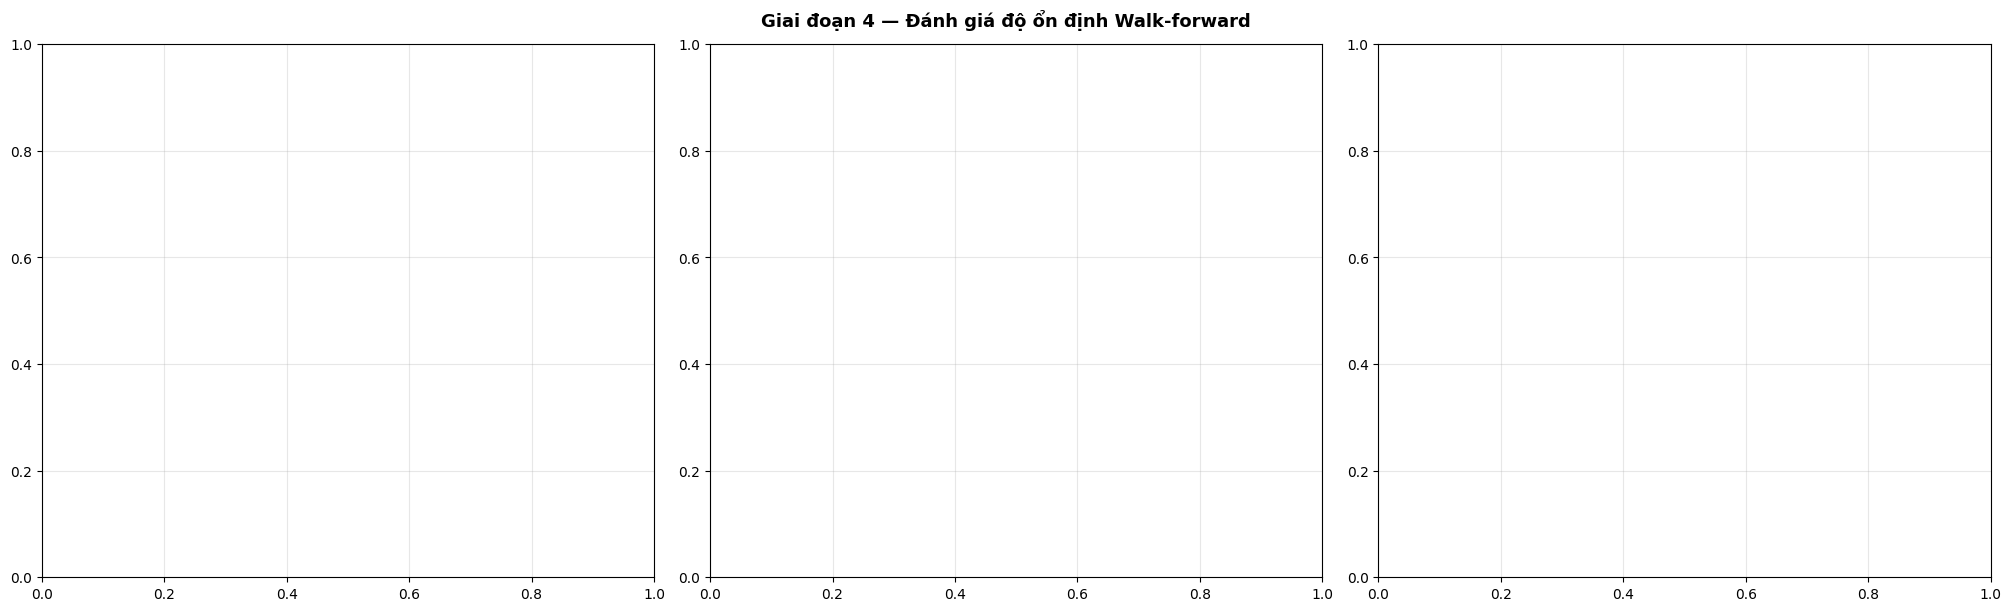

In [33]:
# ─────────────────────────────────────────────
# 9. VISUALISATION
# ─────────────────────────────────────────────

colors_map = {
    "LightGBM": "#1D9E75",
    "XGBoost" : "#534AB7",
    "Ridge"   : "#BA7517",
    "Ensemble": "#2C2C2C",
}

n_folds  = len(all_fold_preds)
n_models = len(MODEL_FACTORIES) + 1
fold_names = [f["name"] for f in FOLDS[:n_folds]]

# ── 9a. 6 đồ thị fold → 1 file ───────────────────────────────────────
fig_folds, axes_folds = plt.subplots(n_folds, 1, figsize=(18, 4 * n_folds),
                                     constrained_layout=True)
if n_folds == 1:
    axes_folds = [axes_folds]

fig_folds.suptitle(
    "Giai đoạn 4 — Walk-forward Validation: Dự báo từng Fold",
    fontsize=13, fontweight="bold"
)

for i, fold_data in enumerate(all_fold_preds):
    ax     = axes_folds[i]
    dates  = pd.to_datetime(fold_data["dates"])
    y_true = fold_data["y_true"]

    ax.plot(dates, y_true / 1e6, color="lightgray", lw=0.9,
            label="Actual", zorder=1)

    for model_name, color in colors_map.items():
        if model_name in fold_data:
            y_pred = fold_data[model_name]
            m      = mape(y_true, y_pred)
            ax.plot(dates, y_pred / 1e6, color=color, lw=1.1,
                    alpha=0.85, label=f"{model_name} (MAPE={m:.1f}%)", zorder=2)

    pred_year = pd.to_datetime(fold_data["dates"][0]).year
    fold_name = FOLDS[i]["name"]
    ax.set_title(
        f"{fold_name} — Predict {pred_year}  "
        f"({'⚡ Structural break' if pred_year == 2020 else ''})",
        fontsize=10
    )
    ax.set_ylabel("Revenue (triệu)")
    ax.legend(fontsize=7, loc="upper right", ncol=2)

    if "Is_High_COGS" in full_fe.columns:
        fold_meta = full_fe[full_fe["Date"].dt.year == pred_year]
        high_cogs = fold_meta[fold_meta["Is_High_COGS"] == 1]["Date"]
        if len(high_cogs) > 0:
            ax.axvspan(high_cogs.iloc[0], high_cogs.iloc[-1],
                       alpha=0.06, color="red", label="High COGS period")

plt.savefig(OUTPUT_DIR / "phase4_folds_forecast.png", dpi=150, bbox_inches="tight")
print(f"  ✓ Đã lưu đồ thị các fold: {OUTPUT_DIR}/phase4_folds_forecast.png")
plt.close(fig_folds)

# ── 9b + 9c. MAPE theo fold + Mean MAPE±Std + Score → 1 file ─────────
fig_mape, axes_mape = plt.subplots(1, 3, figsize=(20, 6), constrained_layout=True)
fig_mape.suptitle(
    "Giai đoạn 4 — Đánh giá độ ổn định Walk-forward",
    fontsize=13, fontweight="bold"
)

# ── 9b. MAPE theo fold (line chart) → file riêng ─────────────────────
fig_line, ax = plt.subplots(figsize=(9, 6), constrained_layout=True)
fig_line.suptitle(
    "Giai đoạn 4 — MAPE theo Fold",
    fontsize=13, fontweight="bold"
)
x = np.arange(len(fold_names))
for model_name, color in colors_map.items():
    if model_name == "Ensemble":
        mapes_line = ens_mapes if ens_mapes else []
    else:
        mapes_line = [
            results[model_name].get(fn, {}).get("mape", np.nan)
            for fn in fold_names
            if model_name in results
        ]
    if mapes_line and not all(np.isnan(mapes_line)):
        ax.plot(x[:len(mapes_line)], mapes_line, "-o", color=color,
                lw=1.8, markersize=6, label=model_name)
        pass
ax.set_xticks(x)
ax.set_xticklabels(fold_names, rotation=15)
ax.set_title("MAPE theo Fold\n(thấp & phẳng = tốt)")
ax.set_ylabel("MAPE (%)")
ax.axvline(4, color="red", ls="--", lw=0.8, alpha=0.5, label="Fold 5: break 2020")
ax.legend(fontsize=8)
plt.savefig(OUTPUT_DIR / "phase4_mape_by_fold.png", dpi=150, bbox_inches="tight")
print(f"  ✓ Đã lưu đồ thị MAPE theo fold: {OUTPUT_DIR}/phase4_mape_by_fold.png")
plt.close(fig_line)

# ── 9c + 9d. Mean MAPE±Std + Score → 1 file ──────────────────────────
fig_bar, axes_bar = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
fig_bar.suptitle(
    "Giai đoạn 4 — Đánh giá độ ổn định Walk-forward",
    fontsize=13, fontweight="bold"
)

models_sorted = final_df["Model"].tolist()
mean_mapes    = final_df["Mean MAPE"].tolist()
std_mapes     = final_df["Std MAPE"].tolist()
scores        = final_df["Score"].tolist()
bar_colors    = [colors_map.get(m, "gray") for m in models_sorted]

# Mean MAPE ± Std
ax = axes_bar[0]
ax.bar(models_sorted, mean_mapes, yerr=std_mapes,
       color=bar_colors, alpha=0.85, edgecolor="white",
       capsize=5, error_kw={"elinewidth": 1.5})
ax.set_title("Mean MAPE ± Std\n(Error bar = biến động giữa các fold)")
ax.set_ylabel("MAPE (%)")
ax.set_xlabel("Mô hình")

# Score tổng hợp
ax = axes_bar[1]
bars2 = ax.bar(models_sorted, scores, color=bar_colors, alpha=0.85, edgecolor="white")
ax.set_title("Score = Mean MAPE + 0.5×Std\n(thấp hơn = tốt hơn)")
ax.set_ylabel("Score")
ax.set_xlabel("Mô hình")
best_idx = models_sorted.index(best_model_name)
bars2[best_idx].set_edgecolor("gold")
bars2[best_idx].set_linewidth(3)

plt.savefig(OUTPUT_DIR / "phase4_mape_score_bars.png", dpi=150, bbox_inches="tight")
print(f"  ✓ Đã lưu đồ thị bar MAPE & Score: {OUTPUT_DIR}/phase4_mape_score_bars.png")
plt.close(fig_bar)

# ── 9e. Revenue + fold context → 1 file ──────────────────────────────
fig_ctx, ax = plt.subplots(figsize=(18, 5))
wf_range = full_fe.copy()
ax.plot(wf_range["Date"], wf_range[TARGET_COL] / 1e6,
        color="lightgray", lw=0.4, alpha=0.6, label="Revenue actual")
roll30 = wf_range.set_index("Date")[TARGET_COL].rolling(30, min_periods=1).mean() / 1e6
ax.plot(roll30.index, roll30.values, color="#534AB7", lw=1.5, label="Rolling 30 ngày")
for i, fold in enumerate(FOLDS[:n_folds]):
    pred_start = pd.Timestamp(f"{fold['pred_year']}-01-01")
    pred_end   = pd.Timestamp(f"{fold['pred_year']}-12-31")
    ax.axvspan(pred_start, pred_end, alpha=0.12,
               color=list(colors_map.values())[i % len(colors_map)],
               label=f"{fold['name']} predict")
ax.axvline(pd.Timestamp("2020-01-01"), color="red", ls="--", lw=1.2,
           alpha=0.8, label="Structural break")
ax.set_title("Revenue và vùng Predict của từng Fold (Walk-forward Context)",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Revenue (triệu)")
ax.legend(fontsize=7, ncol=4, loc="upper left")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "phase4_walkforward_context.png", dpi=150, bbox_inches="tight")
print(f"  ✓ Đã lưu đồ thị context: {OUTPUT_DIR}/phase4_walkforward_context.png")
plt.close(fig_ctx)

### Giai đoạn 5: Đánh giá cuối

In [34]:
# ─────────────────────────────────────────────
# TẢI DỮ LIỆU 
# ─────────────────────────────────────────────

train_fe = pd.read_csv(OUTPUT_DIR / "train_fe.csv",         parse_dates=["Date"])
val_fe   = pd.read_csv(OUTPUT_DIR / "val_fe.csv",           parse_dates=["Date"])
test_fe  = pd.read_csv(OUTPUT_DIR / "test_internal_fe.csv", parse_dates=["Date"])
 
with open(OUTPUT_DIR / "feature_columns.txt", "r", encoding="utf-8") as f:
    feature_cols_raw = [line.strip() for line in f if line.strip()]
 
with open(MODEL_DIR / "walkforward_meta.json", "r", encoding="utf-8") as f:
    wf_meta = json.load(f)
 
# Lọc numeric features (tránh lỗi Period dtype như Giai đoạn 3)
all_fe       = pd.concat([train_fe, val_fe, test_fe], ignore_index=True)
numeric_cols = all_fe.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols_raw
                if c in numeric_cols and c != TARGET_COL]
 
best_model_name = wf_meta["best_model"]          # "Ensemble"
ens_weights     = wf_meta["ensemble_weights"]     # {"LightGBM": 0.351, ...}
wf_mean_mape    = wf_meta["best_mean_mape"]       # 20.17
 
print(f"\n  Mô hình được chọn từ Giai đoạn 4: [{best_model_name}]")
print(f"  Walk-forward Mean MAPE (baseline): {wf_mean_mape:.2f}%")
print(f"  Ensemble weights: {ens_weights}")


  Mô hình được chọn từ Giai đoạn 4: [Ensemble]
  Walk-forward Mean MAPE (baseline): 20.60%
  Ensemble weights: {'XGBoost': 0.3502998940557242, 'LightGBM': 0.3481599041014363, 'Ridge': 0.3015402018428395}


In [35]:
# ─────────────────────────────────────────────
# 1. HELPER FUNCTIONS
# ─────────────────────────────────────────────
 
def get_lgb_model():
    import lightgbm as lgb
    with open(MODEL_DIR / "lgb_best_params.json", "r") as f:
        params = json.load(f)
    return lgb.LGBMRegressor(**params)
 
def get_xgb_model():
    import xgboost as xgb
    with open(MODEL_DIR / "xgb_best_params.json", "r") as f:
        params = json.load(f)
    return xgb.XGBRegressor(**params)
 
def ensemble_predict(models_dict, weights_dict, X):
    """Weighted average prediction từ nhiều mô hình."""
    pred = np.zeros(len(X))
    for name, model in models_dict.items():
        if name in weights_dict:
            pred += model.predict(X) * weights_dict[name]
    return np.clip(pred, 0, None)
 

In [36]:
# ─────────────────────────────────────────────
# 2. CHUẨN BỊ DỮ LIỆU TRAIN (2012-2019) + VAL (2020-2021)
#    ĐỂ TRAIN MÔ HÌNH ĐÁNH GIÁ TEST 2022
# ─────────────────────────────────────────────

train_val_fe = pd.concat([train_fe, val_fe], ignore_index=True).sort_values("Date")
 
X_trainval = train_val_fe[feature_cols].values.astype(np.float64)
y_trainval = train_val_fe[TARGET_COL].values.astype(np.float64)
X_test     = test_fe[feature_cols].values.astype(np.float64)
y_test     = test_fe[TARGET_COL].values.astype(np.float64)
 
# Recency weight: nhấn mạnh 2020-2021 (gần nhất với test 2022)
w_trainval = compute_weights(train_val_fe["Date"])
print(f"\n  Train+Val: {len(train_val_fe):,} ngày "
      f"({train_val_fe['Date'].min().date()} → {train_val_fe['Date'].max().date()})")
print(f"  Test     : {len(test_fe):,} ngày "
      f"({test_fe['Date'].min().date()} → {test_fe['Date'].max().date()})")



  Train+Val: 3,102 ngày (2013-07-05 → 2021-12-31)
  Test     : 365 ngày (2022-01-01 → 2022-12-31)


In [37]:
# ─────────────────────────────────────────────
# 3. ĐÁNH GIÁ CUỐI TRÊN TEST 2022
# ─────────────────────────────────────────────

print("\n[ĐÁNH GIÁ CUỐN CHIẾU TEST 2022 - TẦN SUẤT: HÀNG THÁNG]")

# 1. Khởi tạo tập huấn luyện ban đầu (Từ 2012 đến hết 2021)
current_train_df = train_val_fe.copy()

# Lấy danh sách các kỳ (tháng) duy nhất có trong tập Test 2022
test_months = test_fe["Date"].dt.to_period("M").unique()

pred_test_ensemble_list = []
y_test_list = []
dates_list = []

for current_month in test_months:
    # 2. Tách dữ liệu thực tế của tháng hiện tại ra để đánh giá
    current_test_df = test_fe[test_fe["Date"].dt.to_period("M") == current_month]
    
    if len(current_test_df) == 0:
        continue
        
    print(f" Đang huấn luyện & dự báo cho: {current_month} ({len(current_test_df)} ngày)...")
    
    # 3. Chuẩn bị đặc trưng (Features) từ tập huấn luyện mở rộng hiện tại
    X_train_current = current_train_df[feature_cols].values.astype(np.float64)
    y_train_current = current_train_df[TARGET_COL].values.astype(np.float64)
    w_train_current = compute_weights(current_train_df["Date"])
    
    X_test_current  = current_test_df[feature_cols].values.astype(np.float64)
    
    eval_models = {}
    
    # 4. Retrain các mô hình trên tập dữ liệu đã gộp
    try:
        lgb_eval = get_lgb_model()
        lgb_eval.fit(X_train_current, y_train_current, sample_weight=w_train_current)
        eval_models["LightGBM"] = lgb_eval
    except Exception as e:
        print(f"   ✗ Lỗi LightGBM: {e}")
        
    try:
        xgb_eval = get_xgb_model()
        xgb_eval.fit(X_train_current, y_train_current, sample_weight=w_train_current, verbose=False)
        eval_models["XGBoost"] = xgb_eval
    except Exception as e:
        print(f"   ✗ Lỗi XGBoost: {e}")
        
    # 5. Thực hiện dự báo cho tháng hiện tại
    w_avail = {k: ens_weights[k] for k in eval_models if k in ens_weights}
    total_w = sum(w_avail.values())
    if total_w > 0:
        w_avail = {k: v / total_w for k, v in w_avail.items()}
    else:
        w_avail = {k: 1.0 / len(eval_models) for k in eval_models}
    
    pred_current = ensemble_predict(eval_models, w_avail, X_test_current)
    
    # Lưu lại kết quả dự báo
    pred_test_ensemble_list.extend(pred_current)
    y_test_list.extend(current_test_df[TARGET_COL].values)
    dates_list.extend(current_test_df["Date"].values)
    
    current_train_df = pd.concat([current_train_df, current_test_df], ignore_index=True)

# 7. Tổng hợp lại toàn bộ mảng dự báo cho năm 2022
pred_test_ensemble = np.array(pred_test_ensemble_list)
y_test_arr = np.array(y_test_list)

# Cập nhật kết quả vào dataframe để Phase 4 (Phân tích lỗi) tiếp tục chạy bình thường
test_analysis = pd.DataFrame({
    "Date": dates_list,
    "y_true": y_test_arr,
    "y_pred": pred_test_ensemble
})
# Đồng bộ lại pred_test_ensemble để các code vẽ chart bên dưới không bị lỗi
pred_test_ensemble = test_analysis["y_pred"].values 
y_test = test_analysis["y_true"].values

# Tính toán Metrics tổng thể cho năm 2022 sau khi đi hết vòng cuốn chiếu
test_mape = mape(y_test_arr, pred_test_ensemble)
test_rmse = rmse(y_test_arr, pred_test_ensemble)
test_mae  = mae(y_test_arr, pred_test_ensemble)
test_r2   = r2(y_test_arr, pred_test_ensemble)

print(f"\n [TỔNG KẾT ENSEMBLE CUỐN CHIẾU — Test 2022]")
print(f"   MAPE : {test_mape:.2f}%")
print(f"   RMSE : {test_rmse:,.0f}")
print(f"   MAE  : {test_mae:,.0f}")
print(f"   R²   : {test_r2:.4f}")

# Tính chênh lệch với walk-forward baseline
gap = test_mape - wf_mean_mape
print(f"\n   Walk-forward Mean MAPE: {wf_mean_mape:.2f}%")
print(f"   Test 2022 MAPE        : {test_mape:.2f}%")
print(f"   Chênh lệch            : {gap:+.2f}%")

if abs(gap) <= 3:
    print("   ✓ Mô hình tổng quát TỐT — chênh lệch <= 3%")
elif abs(gap) <= 5:
    print("   ⚠ Chênh lệch nhỏ (3–5%) — chấp nhận được, tiếp tục")
else:
    print("   ✗ Chênh lệch lớn > 5% — cần xem xét thêm trước khi nộp")


[ĐÁNH GIÁ CUỐN CHIẾU TEST 2022 - TẦN SUẤT: HÀNG THÁNG]
 Đang huấn luyện & dự báo cho: 2022-01 (31 ngày)...
 Đang huấn luyện & dự báo cho: 2022-02 (28 ngày)...
 Đang huấn luyện & dự báo cho: 2022-03 (31 ngày)...
 Đang huấn luyện & dự báo cho: 2022-04 (30 ngày)...
 Đang huấn luyện & dự báo cho: 2022-05 (31 ngày)...
 Đang huấn luyện & dự báo cho: 2022-06 (30 ngày)...
 Đang huấn luyện & dự báo cho: 2022-07 (31 ngày)...
 Đang huấn luyện & dự báo cho: 2022-08 (31 ngày)...
 Đang huấn luyện & dự báo cho: 2022-09 (30 ngày)...
 Đang huấn luyện & dự báo cho: 2022-10 (31 ngày)...
 Đang huấn luyện & dự báo cho: 2022-11 (30 ngày)...
 Đang huấn luyện & dự báo cho: 2022-12 (31 ngày)...

 [TỔNG KẾT ENSEMBLE CUỐN CHIẾU — Test 2022]
   MAPE : 19.67%
   RMSE : 708,209
   MAE  : 527,510
   R²   : 0.8210

   Walk-forward Mean MAPE: 20.60%
   Test 2022 MAPE        : 19.67%
   Chênh lệch            : -0.93%
   ✓ Mô hình tổng quát TỐT — chênh lệch <= 3%


In [38]:
# ─────────────────────────────────────────────
# 4. PHÂN TÍCH LỖI CHI TIẾT TRÊN TEST 2022
# ─────────────────────────────────────────────

test_analysis = test_fe[["Date"]].copy()
test_analysis["y_true"]     = y_test
test_analysis["y_pred"]     = pred_test_ensemble
test_analysis["residual"]   = test_analysis["y_true"] - test_analysis["y_pred"]
test_analysis["abs_pct_err"]= np.abs(test_analysis["residual"] / test_analysis["y_true"]) * 100
test_analysis["Month"]      = test_analysis["Date"].dt.month
test_analysis["DayOfWeek"]  = test_analysis["Date"].dt.dayofweek
 
# Lỗi theo tháng
monthly_err = test_analysis.groupby("Month")["abs_pct_err"].agg(["mean", "std"]).round(2)
monthly_err.columns = ["MAPE_month", "Std_month"]
print(f"\n  [Lỗi theo tháng (2022)]")
print(monthly_err.to_string())
worst_month = monthly_err["MAPE_month"].idxmax()
best_month  = monthly_err["MAPE_month"].idxmin()
print(f"\n  Tháng predict kém nhất: T{worst_month} "
      f"({monthly_err.loc[worst_month,'MAPE_month']:.1f}%)")
print(f"  Tháng predict tốt nhất: T{best_month}  "
      f"({monthly_err.loc[best_month,'MAPE_month']:.1f}%)")
 
# Lỗi theo thứ trong tuần
dow_err = test_analysis.groupby("DayOfWeek")["abs_pct_err"].mean().round(2)
dow_labels = {0:"T2",1:"T3",2:"T4",3:"T5",4:"T6",5:"T7",6:"CN"}
print(f"\n  [Lỗi theo thứ trong tuần]")
for dow, err in dow_err.items():
    bar = "█" * int(err / 2)
    print(f"    {dow_labels[dow]}: {err:5.1f}%  {bar}")
 
# Bias check: mô hình có xu hướng over/underestimate không?
mean_res = test_analysis["residual"].mean()
bias_pct  = mean_res / test_analysis["y_true"].mean() * 100
print(f"\n  [Bias check]")
print(f"    Mean residual    : {mean_res:+,.0f}")
print(f"    Bias %           : {bias_pct:+.2f}%")
if bias_pct > 2:
    print("    → Mô hình có xu hướng UNDERESTIMATE (predict thấp hơn thực tế)")
elif bias_pct < -2:
    print("    → Mô hình có xu hướng OVERESTIMATE (predict cao hơn thực tế)")
else:
    print("    → Không có bias đáng kể ✓")


  [Lỗi theo tháng (2022)]
       MAPE_month  Std_month
Month                       
1           20.07      12.31
2           18.13      16.82
3           16.55      21.45
4           15.86      17.72
5           22.10      22.34
6           11.74      10.89
7           19.03      20.89
8           18.23      16.35
9           22.96      22.58
10          14.51      14.58
11          33.86      28.09
12          23.01      17.56

  Tháng predict kém nhất: T11 (33.9%)
  Tháng predict tốt nhất: T6  (11.7%)

  [Lỗi theo thứ trong tuần]
    T2:  18.9%  █████████
    T3:  18.1%  █████████
    T4:  20.9%  ██████████
    T5:  18.8%  █████████
    T6:  21.9%  ██████████
    T7:  22.9%  ███████████
    CN:  16.2%  ████████

  [Bias check]
    Mean residual    : +8,844
    Bias %           : +0.28%
    → Không có bias đáng kể ✓


In [39]:
# ─────────────────────────────────────────────
# 5. RETRAIN TRÊN TOÀN BỘ 2012–2022
# ─────────────────────────────────────────────
 
full_fe_all = pd.concat([train_fe, val_fe, test_fe],
                         ignore_index=True).sort_values("Date").reset_index(drop=True)
X_full = full_fe_all[feature_cols].values.astype(np.float64)
y_full = full_fe_all[TARGET_COL].values.astype(np.float64)
w_full = compute_weights(full_fe_all["Date"])
 
print(f"\n  Full data: {len(full_fe_all):,} ngày "
      f"({full_fe_all['Date'].min().date()} → {full_fe_all['Date'].max().date()})")
print(f"  Weight: ngày đầu={w_full[:30].mean():.3f}  ngày cuối={w_full[-30:].mean():.3f}  "
      f"(tỷ lệ {w_full[-30:].mean()/w_full[:30].mean():.1f}x)")
 
final_models = {}
 
try:
    lgb_final = get_lgb_model()
    lgb_final.fit(X_full, y_full, sample_weight=w_full)
    final_models["LightGBM"] = lgb_final
    with open(MODEL_DIR / "lgb_final.pkl", "wb") as f:
        pickle.dump(lgb_final, f)
    print(f"  ✓ LightGBM retrained & saved → lgb_final.pkl")
except Exception as e:
    print(f"  ✗ LightGBM retrain: {e}")
 
try:
    xgb_final = get_xgb_model()
    xgb_final.fit(X_full, y_full, sample_weight=w_full, verbose=False)
    final_models["XGBoost"] = xgb_final
    with open(MODEL_DIR / "xgb_final.pkl", "wb") as f:
        pickle.dump(xgb_final, f)
    print(f"  ✓ XGBoost retrained & saved → xgb_final.pkl")
except Exception as e:
    print(f"  ✗ XGBoost retrain: {e}")
 
# Sanity check: predict lại trên 2022 sau retrain
w_avail = {k: ens_weights[k] for k in final_models if k in ens_weights}
total_w  = sum(w_avail.values())
w_avail  = {k: v / total_w for k, v in w_avail.items()}
pred_sanity = ensemble_predict(final_models, w_avail, X_test)
mape_sanity = mape(y_test, pred_sanity)
print(f"\n  [Sanity check] MAPE trên 2022 sau retrain: {mape_sanity:.2f}%")


  Full data: 3,467 ngày (2013-07-05 → 2022-12-31)
  Weight: ngày đầu=0.633  ngày cuối=2.374  (tỷ lệ 3.7x)
  ✓ LightGBM retrained & saved → lgb_final.pkl
  ✓ XGBoost retrained & saved → xgb_final.pkl

  [Sanity check] MAPE trên 2022 sau retrain: 5.96%


In [40]:
# ─────────────────────────────────────────────
# 6. DỰ BÁO CHO 2023-2024 (RECURSIVE FORECASTING)
# ─────────────────────────────────────────────

# Tạo date range cho tập test ẩn
TEST_HIDDEN_START = "2023-01-01"
TEST_HIDDEN_END   = "2024-07-01"
hidden_dates = pd.date_range(TEST_HIDDEN_START, TEST_HIDDEN_END, freq="D")
print(f"\n Tập test ẩn: {hidden_dates[0].date()} → {hidden_dates[-1].date()} ({len(hidden_dates):,} ngày)")

# Khởi tạo bản sao của dữ liệu lịch sử để đắp dần dự báo vào
recursive_df = full_fe_all[["Date", "Revenue", "COGS", "COGS_margin"]].copy()

# Fix hằng số Covid Shock (Tính 1 lần)
COVID_START_DATE = pd.to_datetime("2019-01-01")
LAMBDA_DECAY_RATE = 0.004

predicted_revenues = []

print("\n Bắt đầu dự báo đệ quy (Recursive Forecasting)...")
for current_date in hidden_dates:
    
    # 1. Thêm một dòng trống cho ngày hiện tại (target đang là NaN)
    new_row = pd.DataFrame({
        "Date": [current_date],
        "Revenue": [np.nan],
        "COGS": [np.nan],
        "COGS_margin": [recursive_df["COGS_margin"].iloc[-1]] # Giữ nguyên margin gần nhất
    })
    recursive_df = pd.concat([recursive_df, new_row], ignore_index=True)
    
    # --- TỐI ƯU HÓA: Chỉ lấy đoạn dữ liệu đủ để tính lag lớn nhất (lag 365) ---
    window_df = recursive_df.tail(400).copy().reset_index(drop=True)
    
    # 2. FEATURE ENGINEERING CHO NGÀY HIỆN TẠI (Tính trên window_df)
    
    # Covid Shock
    days_since_covid = (window_df["Date"] - COVID_START_DATE).dt.days.clip(lower=0)
    window_df["Covid_Decay_Shock"] = np.where(
        window_df["Date"] < COVID_START_DATE, 0.0, np.exp(-LAMBDA_DECAY_RATE * days_since_covid)
    )
    
    # Lags
    for lag in [1, 7, 14, 30, 365]:
        window_df[f"Revenue_lag{lag}"] = window_df["Revenue"].shift(lag)
    for lag in [1, 7, 30]:
        window_df[f"COGS_lag{lag}"] = window_df["COGS"].shift(lag)
        window_df[f"COGS_margin_lag{lag}"] = window_df["COGS_margin"].shift(lag)

    # Rolling
    rev_sh = window_df["Revenue"].shift(1)
    cog_sh = window_df["COGS"].shift(1)
    for w in [7, 14, 30, 90]:
        window_df[f"Revenue_roll_mean{w}"] = rev_sh.rolling(w, min_periods=max(1,w//2)).mean()
        window_df[f"COGS_roll_mean{w}"]    = cog_sh.rolling(w, min_periods=max(1,w//2)).mean()
        window_df[f"Revenue_roll_std{w}"]  = rev_sh.rolling(w, min_periods=max(1,w//2)).std()
        window_df[f"Revenue_roll_max{w}"]  = rev_sh.rolling(w, min_periods=max(1,w//2)).max()
        window_df[f"Revenue_roll_min{w}"]  = rev_sh.rolling(w, min_periods=max(1,w//2)).min()

    window_df["Revenue_ratio_7_30"]  = window_df["Revenue_roll_mean7"]  / (window_df["Revenue_roll_mean30"]  + 1e-8)
    window_df["Revenue_ratio_14_90"] = window_df["Revenue_roll_mean14"] / (window_df["Revenue_roll_mean90"]  + 1e-8)

    # Calendar
    window_df["DayOfWeek"] = window_df["Date"].dt.dayofweek
    window_df["DayOfMonth"] = window_df["Date"].dt.day
    window_df["DayOfYear"] = window_df["Date"].dt.dayofyear
    window_df["WeekOfYear"] = window_df["Date"].dt.isocalendar().week.astype(int)
    window_df["Month"] = window_df["Date"].dt.month
    window_df["Quarter"] = window_df["Date"].dt.quarter
    window_df["Year"] = window_df["Date"].dt.year
    window_df["Is_Weekend"] = (window_df["DayOfWeek"] >= 5).astype(int)
    window_df["Is_MonthEnd"] = window_df["Date"].dt.is_month_end.astype(int)
    window_df["Is_MonthStart"] = window_df["Date"].dt.is_month_start.astype(int)
    window_df["Is_QuarterEnd"] = window_df["Date"].dt.is_quarter_end.astype(int)

    window_df["DOW_sin"] = np.sin(2 * np.pi * window_df["DayOfWeek"] / 7)
    window_df["DOW_cos"] = np.cos(2 * np.pi * window_df["DayOfWeek"] / 7)
    window_df["Month_sin"] = np.sin(2 * np.pi * window_df["Month"] / 12)
    window_df["Month_cos"] = np.cos(2 * np.pi * window_df["Month"] / 12)
    window_df["DOY_sin"] = np.sin(2 * np.pi * window_df["DayOfYear"] / 365)
    window_df["DOY_cos"] = np.cos(2 * np.pi * window_df["DayOfYear"] / 365)
    days_in_month = window_df["Date"].dt.days_in_month
    window_df["DOM_sin"] = np.sin(2 * np.pi * window_df["DayOfMonth"] / days_in_month)
    window_df["DOM_cos"] = np.cos(2 * np.pi * window_df["DayOfMonth"] / days_in_month)


    for k in range(1, 4):
        window_df[f"Fourier_sin_{k}"] = np.sin(2 * np.pi * k * window_df["DayOfYear"] / 365)
        window_df[f"Fourier_cos_{k}"] = np.cos(2 * np.pi * k * window_df["DayOfYear"] / 365)

    t0 = full_fe_all["Date"].min() # Dùng t0 gốc
    window_df["Time_idx"] = (window_df["Date"] - t0).dt.days

    window_df["Time_idx_post"] = np.where(
        window_df["Date"] >= pd.Timestamp("2020-01-01"),
        (window_df["Date"] - pd.Timestamp("2020-01-01")).dt.days, 0
    )

    # Ratios & Growth features
    window_df["COGS_to_Revenue"]      = window_df["COGS"] / (window_df["Revenue"] + 1e-8)
    window_df["COGS_margin_diff1"]    = window_df["COGS_margin"].diff(1)
    window_df["COGS_margin_roll7"]    = window_df["COGS_margin"].shift(1).rolling(7, min_periods=1).mean()
    window_df["Revenue_diff1"]        = window_df["Revenue"].shift(1).diff(1)
    window_df["Revenue_diff7"]        = window_df["Revenue"].shift(1).diff(7)

    # Ratios & Interaction
    window_df["Revenue_yoy_growth"] = (window_df["Revenue_lag365"] - window_df["Revenue"].shift(366)) / (window_df["Revenue"].shift(366).abs() + 1e-8)
    window_df["Revenue_mom_growth"] = (window_df["Revenue_lag30"] - window_df["Revenue"].shift(31)) / (window_df["Revenue"].shift(31).abs() + 1e-8)
    window_df["Revenue_vs_roll30"]  = (window_df["Revenue_lag1"] - window_df["Revenue_roll_mean30"]) / (window_df["Revenue_roll_std30"] + 1e-8)
    
    window_df["Lag1_x_Covid"] = window_df["Revenue_lag1"] * window_df["Covid_Decay_Shock"]
    window_df["RollMean30_x_Covid"] = window_df["Revenue_roll_mean30"] * window_df["Covid_Decay_Shock"]
    window_df["Weekend_x_Month_sin"] = window_df["Is_Weekend"] * window_df["Month_sin"]
    window_df["Weekend_x_Month_cos"] = window_df["Is_Weekend"] * window_df["Month_cos"]

    # 3. TRÍCH XUẤT VECTOR ĐẶC TRƯNG CỦA NGÀY HIỆN TẠI
    current_day_features = window_df.iloc[-1:]
    
    # Fill NaN bằng median của train nếu có biến nào bị sót (ví dụ lag 365 ở những ngày đầu tiên nếu thiếu data)
    for col in feature_cols:
        if current_day_features[col].isnull().any():
            current_day_features[col] = current_day_features[col].fillna(train_medians.get(col, 0))

    X_current = current_day_features[feature_cols].values.astype(np.float64)

    # 4. THỰC HIỆN DỰ BÁO
    pred = ensemble_predict(final_models, w_avail, X_current)[0]
    
    # 5. CẬP NHẬT KẾT QUẢ VÀO DF GỐC ĐỂ DÙNG CHO VÒNG LẶP TIẾP THEO
    recursive_df.loc[recursive_df.index[-1], "Revenue"] = pred
    recursive_df.loc[recursive_df.index[-1], "COGS"] = pred * recursive_df["COGS_margin"].iloc[-1]
    
    predicted_revenues.append(pred)

# Lưu lại kết quả
pred_hidden = np.array(predicted_revenues)
hidden_fe = recursive_df[recursive_df["Date"].isin(hidden_dates)].copy()




 Tập test ẩn: 2023-01-01 → 2024-07-01 (548 ngày)

 Bắt đầu dự báo đệ quy (Recursive Forecasting)...


In [41]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────
# 7. TẠO VÀ LƯU KẾT QUẢ DỰ BÁO (CSV & PDF)
# ─────────────────────────────────────────────

# 1. Tạo DataFrame kết quả cuối cùng
submission = pd.DataFrame({
    "Date": hidden_fe["Date"].dt.date.values,
    "Revenue": pred_hidden.round(2),
    # Giả định tỷ lệ COGS_margin được giữ nguyên theo ngày cuối cùng của tập train
    "COGS": (pred_hidden * recursive_df["COGS_margin"].iloc[-1]).round(2),
})

# 2. Lưu file CSV (Dữ liệu bảng thô)
submission_path_csv = SUBMIT_DIR / "predictions_2023_2024.csv"
submission.to_csv(submission_path_csv, index=False)
print(f"\n ✓ Đã lưu file dữ liệu CSV: {submission_path_csv}")

# 3. Xuất báo cáo PDF (Biểu đồ trực quan)
submission_path_pdf = SUBMIT_DIR / "predictions_report_2023_2024.pdf"

with PdfPages(submission_path_pdf) as pdf:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Vẽ đường dự báo
    ax.plot(pd.to_datetime(submission["Date"]), submission["Revenue"] / 1e6, 
            color="#534AB7", lw=1.5, label="Predicted Revenue")
    
    # Định dạng biểu đồ
    ax.set_title("Dự báo Doanh thu 2023 - 2024 (Recursive Forecasting)", 
                 fontsize=14, fontweight="bold", pad=15)
    ax.set_xlabel("Thời gian", fontsize=11)
    ax.set_ylabel("Doanh thu (triệu)", fontsize=11)
    ax.grid(alpha=0.3, linestyle="--")
    ax.legend(loc="upper left")
    
    # Tự động căn chỉnh bố cục
    plt.tight_layout()
    
    # Lưu figure hiện tại vào PDF
    pdf.savefig(fig)
    plt.close()

print(f" ✓ Đã lưu báo cáo biểu đồ PDF: {submission_path_pdf}")

# In Preview
print(f"\n Preview 5 dòng đầu tiên:")
print(submission.head().to_string(index=False))


 ✓ Đã lưu file dữ liệu CSV: output\submission\predictions_2023_2024.csv
 ✓ Đã lưu báo cáo biểu đồ PDF: output\submission\predictions_report_2023_2024.pdf

 Preview 5 dòng đầu tiên:
      Date    Revenue       COGS
2023-01-01 2523415.60 2413554.66
2023-01-02 2052723.60 1963354.99
2023-01-03 1441107.77 1378366.84
2023-01-04  509985.34  487782.31
2023-01-05  877836.35  839618.34


In [42]:
# ─────────────────────────────────────────────
# 7. VISUALISATION TỔNG HỢP
# ─────────────────────────────────────────────
print("\n[VISUALISATION]")

colors = {"train": "#1D9E75", "val": "#BA7517",
          "test": "#D85A30",  "pred": "#534AB7"}

# ── 7a. Full timeline ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train_fe["Date"], train_fe["Revenue"] / 1e6,
        color=colors["train"], lw=0.5, alpha=0.6, label="Train 2012-2019")
ax.plot(val_fe["Date"],   val_fe["Revenue"]   / 1e6,
        color=colors["val"],   lw=0.5, alpha=0.6, label="Val 2020-2021")
ax.plot(test_fe["Date"],  test_fe["Revenue"]  / 1e6,
        color=colors["test"],  lw=0.5, alpha=0.7, label="Test 2022 (actual)")
ax.plot(hidden_fe["Date"], pred_hidden / 1e6,
        color=colors["pred"],  lw=1.0, alpha=0.85, label="Predictions 2023-2024")
ax.axvline(pd.Timestamp("2023-01-01"), color="black", ls="--", lw=1,
           alpha=0.7, label="Ranh giới nộp bài")
ax.set_title("Full Timeline: Train → Val → Test → Predictions",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Revenue (triệu)")
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "phase5_7a_full_timeline.png", dpi=150, bbox_inches="tight")
plt.close()
print("  ✓ Đã lưu: phase5_7a_full_timeline.png")

# ── 7b. Test 2022: Actual vs Predicted ───────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test_fe["Date"], y_test / 1e6,
        color="lightgray", lw=0.8, label="Actual 2022")
ax.plot(test_fe["Date"], pred_test_ensemble / 1e6,
        color=colors["test"], lw=1.1, label=f"Ensemble (MAPE={test_mape:.1f}%)")
ax.set_title(f"Test 2022 — Actual vs Predicted\nMAPE={test_mape:.2f}%  RMSE={test_rmse:,.0f}",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Revenue (triệu)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "phase5_7b_test2022_actual_vs_pred.png", dpi=150, bbox_inches="tight")
plt.close()
print("  ✓ Đã lưu: phase5_7b_test2022_actual_vs_pred.png")

# ── 7c. MAPE theo tháng 2022 ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
month_names = ["T1","T2","T3","T4","T5","T6",
               "T7","T8","T9","T10","T11","T12"]
ax.bar(range(1, 13), monthly_err["MAPE_month"],
       color=colors["test"], alpha=0.8, edgecolor="white")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.axhline(test_mape, color="red", ls="--", lw=1,
           label=f"Mean MAPE={test_mape:.1f}%")
ax.set_title("MAPE theo tháng (Test 2022)", fontsize=12, fontweight="bold")
ax.set_ylabel("MAPE (%)")
ax.legend(fontsize=8)
for i, val in enumerate(monthly_err["MAPE_month"]):
    ax.text(i + 1, val + 0.2, f"{val:.1f}%",
            ha="center", va="bottom", fontsize=7)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "phase5_7c_mape_by_month.png", dpi=150, bbox_inches="tight")
plt.close()
print("  ✓ Đã lưu: phase5_7c_mape_by_month.png")

# ── 7d. Residual analysis ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
residuals = test_analysis["residual"] / 1e6
ax.plot(test_fe["Date"], residuals,
        color=colors["test"], lw=0.6, alpha=0.7)
ax.axhline(0,               color="red",    ls="--", lw=1, label="Zero")
ax.axhline(residuals.mean(), color="orange", ls=":",  lw=1,
           label=f"Mean={residuals.mean():.2f}M (bias)")
ax.fill_between(test_fe["Date"],
                residuals.mean() - residuals.std(),
                residuals.mean() + residuals.std(),
                alpha=0.1, color="orange", label="±1 Std")
ax.set_title(f"Residuals — Test 2022  (Bias={bias_pct:+.1f}%)",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Residual (triệu)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "phase5_7d_residuals_time.png", dpi=150, bbox_inches="tight")
plt.close()
print("  ✓ Đã lưu: phase5_7d_residuals_time.png")

# ── 7e. Predictions 2023-2024 (full view) ────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
context = test_fe[test_fe["Date"] >= "2022-07-01"]
ax.plot(context["Date"], context["Revenue"] / 1e6,
        color=colors["test"], lw=0.8, alpha=0.7, label="Actual 2022 (H2)")
ax.plot(hidden_fe["Date"], pred_hidden / 1e6,
        color=colors["pred"], lw=1.2, label="Predictions 2023-2024")
ax.axvline(pd.Timestamp("2023-01-01"), color="black",
           ls="--", lw=1, alpha=0.7)
rolling_pred = pd.Series(pred_hidden).rolling(30, min_periods=1).mean() / 1e6
ax.plot(hidden_fe["Date"], rolling_pred,
        color="navy", lw=1.5, ls="--", label="Rolling 30 ngày (trend)")
ax.set_title("Predictions 2023–2024 với context 2022",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Revenue (triệu)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "phase5_7e_predictions_2023_2024.png", dpi=150, bbox_inches="tight")
plt.close()
print("  ✓ Đã lưu: phase5_7e_predictions_2023_2024.png")

# ── 7f. Monthly predictions 2023-2024 ────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
pred_df = pd.DataFrame({
    "Date"   : hidden_fe["Date"].values,
    "Revenue": pred_hidden
})
pred_df["YearMonth"] = pd.to_datetime(pred_df["Date"]).dt.to_period("M")
monthly_pred = pred_df.groupby("YearMonth")["Revenue"].sum() / 1e6
x_labels = [str(p) for p in monthly_pred.index]
pred_colors = ["#1D9E75" if str(p)[:4] == "2023" else "#534AB7"
               for p in monthly_pred.index]
ax.bar(range(len(monthly_pred)), monthly_pred.values,
       color=pred_colors, alpha=0.85, edgecolor="white")
ax.set_xticks(range(len(monthly_pred)))
ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=7)
ax.set_title("Revenue dự báo theo tháng (2023–2024)",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Revenue (triệu/tháng)")
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="#1D9E75", label="2023"),
    Patch(color="#534AB7", label="2024"),
], fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "phase5_7f_monthly_pred_2023_2024.png", dpi=150, bbox_inches="tight")
plt.close()
print("  ✓ Đã lưu: phase5_7f_monthly_pred_2023_2024.png")

# ── 7g. Walk-forward summary ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
model_names   = [r["Model"]     for r in wf_meta["stability_table"]]
model_mapes   = [r["Mean MAPE"] for r in wf_meta["stability_table"]]
model_stds    = [r["Std MAPE"]  for r in wf_meta["stability_table"]]
bar_colors_wf = ["gold" if n == best_model_name else "steelblue"
                 for n in model_names]
ax.bar(model_names, model_mapes, yerr=model_stds,
       color=bar_colors_wf, alpha=0.85, edgecolor="white",
       capsize=5, error_kw={"elinewidth": 1.5})
ax.axhline(test_mape, color="red", ls="--", lw=1,
           label=f"Test 2022 MAPE ({test_mape:.1f}%)")
ax.set_title("Walk-forward vs Test 2022 MAPE",
             fontsize=12, fontweight="bold")
ax.set_ylabel("MAPE (%)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "phase5_7g_walkforward_summary.png", dpi=150, bbox_inches="tight")
plt.close()
print("  ✓ Đã lưu: phase5_7g_walkforward_summary.png")

# ── 7h. Residual distribution ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(test_analysis["abs_pct_err"], bins=40,
        color=colors["test"], alpha=0.8, edgecolor="white")
ax.axvline(test_mape, color="red", ls="--", lw=1,
           label=f"MAPE={test_mape:.1f}%")
ax.axvline(10, color="green", ls=":", lw=1, label="10% threshold")
pct_under10 = (test_analysis["abs_pct_err"] < 10).mean() * 100
ax.set_title(f"Phân phối |Error %| — Test 2022\n"
             f"{pct_under10:.1f}% dự báo có lỗi < 10%",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Absolute % Error")
ax.set_ylabel("Số ngày")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "phase5_7h_error_distribution.png", dpi=150, bbox_inches="tight")
plt.close()
print("  ✓ Đã lưu: phase5_7h_error_distribution.png")


[VISUALISATION]
  ✓ Đã lưu: phase5_7a_full_timeline.png
  ✓ Đã lưu: phase5_7b_test2022_actual_vs_pred.png
  ✓ Đã lưu: phase5_7c_mape_by_month.png
  ✓ Đã lưu: phase5_7d_residuals_time.png
  ✓ Đã lưu: phase5_7e_predictions_2023_2024.png
  ✓ Đã lưu: phase5_7f_monthly_pred_2023_2024.png
  ✓ Đã lưu: phase5_7g_walkforward_summary.png
  ✓ Đã lưu: phase5_7h_error_distribution.png


## Giai đoạn 6: Giải thích mô hình với SHAP

In [43]:
# ─────────────────────────────────────────────
# Giải thích mô hình với SHAP (Ensemble-aware)
# ─────────────────────────────────────────────

try:

    SHAP_DIR = OUTPUT_DIR / "shap_analysis"
    SHAP_DIR.mkdir(parents=True, exist_ok=True)

    # ── Bước 1: Đọc trọng số Ensemble từ walkforward_meta.json ────────
    meta_path = OUTPUT_DIR / "models" / "walkforward_meta.json"
    with open(meta_path, "r", encoding="utf-8") as f:
        meta = json.load(f)

    ensemble_weights: dict = meta["ensemble_weights"]
    w_xgb  = ensemble_weights.get("XGBoost",  0.0)
    w_lgbm = ensemble_weights.get("LightGBM", 0.0)
    w_ridge = ensemble_weights.get("Ridge",   0.0)

    total_w = w_xgb + w_lgbm + w_ridge
    if abs(total_w - 1.0) > 1e-6:
        print(f"  ⚠ Tổng trọng số = {total_w:.4f} ≠ 1. Tiến hành chuẩn hóa lại.")
        w_xgb  /= total_w
        w_lgbm /= total_w
        w_ridge /= total_w

    print(f"  Trọng số Ensemble — XGBoost: {w_xgb:.3f} | "
          f"LightGBM: {w_lgbm:.3f} | Ridge: {w_ridge:.3f}")

    # ── Bước 2: Chuẩn bị dữ liệu đầu vào ─────────────────────────────
    X_test_df = pd.DataFrame(X_test, columns=feature_cols)
    X_train_df = pd.DataFrame(X_trainval, columns=feature_cols)
    
     # ── Bước 3: Tính ma trận SHAP cho từng thành viên ─────────────────
    shap_matrices:  dict[str, np.ndarray] = {}
    base_val_store: dict[str, float]      = {}   # ← lưu expected_value ngay tại đây

    # 3a. TreeExplainer cho XGBoost
    if w_xgb > 0 and "XGBoost" in final_models:
        print("  → Đang tính SHAP cho XGBoost  (TreeExplainer) ...")
        exp_xgb  = shap.TreeExplainer(final_models["XGBoost"])
        sv_xgb   = exp_xgb.shap_values(X_test_df)
        shap_matrices["XGBoost"]  = np.array(sv_xgb)
        base_val_store["XGBoost"] = float(np.atleast_1d(exp_xgb.expected_value)[0])

    # 3b. TreeExplainer cho LightGBM
    if w_lgbm > 0 and "LightGBM" in final_models:
        print("  → Đang tính SHAP cho LightGBM (TreeExplainer) ...")
        exp_lgbm  = shap.TreeExplainer(final_models["LightGBM"])
        sv_lgbm   = exp_lgbm.shap_values(X_test_df)
        shap_matrices["LightGBM"]  = np.array(sv_lgbm)
        base_val_store["LightGBM"] = float(np.atleast_1d(exp_lgbm.expected_value)[0])

    # 3c. LinearExplainer cho Ridge
    if w_ridge > 0 and "Ridge" in final_models:
        print("  → Đang tính SHAP cho Ridge    (LinearExplainer) ...")
        _bg       = shap.maskers.Independent(
                        X_train_df if "X_train_df" in dir() else X_test_df,
                        max_samples=500)
        exp_ridge = shap.LinearExplainer(final_models["Ridge"], _bg)
        sv_ridge  = exp_ridge.shap_values(X_test_df)
        shap_matrices["Ridge"]  = np.array(sv_ridge)
        base_val_store["Ridge"] = float(np.atleast_1d(exp_ridge.expected_value)[0])

    # ── Bước 4: Tổng hợp ma trận SHAP có trọng số ─────────────────────
    n_samples, n_features = X_test_df.shape
    shap_ensemble = np.zeros((n_samples, n_features), dtype=np.float64)

    weight_map = {"XGBoost": w_xgb, "LightGBM": w_lgbm, "Ridge": w_ridge}
    for model_name, sv in shap_matrices.items():
        shap_ensemble += weight_map[model_name] * sv
        print(f"  ✓ Đã cộng SHAP_{model_name} × {weight_map[model_name]:.3f}")

    # Base value tổng hợp — tái sử dụng expected_value đã lưu, KHÔNG khởi tạo lại explainer
    base_values_ensemble = sum(
        weight_map[m] * base_val_store[m]
        for m in shap_matrices
    )
    print(f"  Base value Ensemble (E[f(X)]): {base_values_ensemble:,.2f}")

    # ── Bước 5: Xây dựng shap.Explanation object cho Ensemble ─────────
    shap_explanation = shap.Explanation(
        values        = shap_ensemble,
        base_values   = np.full(n_samples, base_values_ensemble),
        data          = X_test_df.values,
        feature_names = feature_cols,
    )
    # ── 6a. Summary Plot (Giải thích toàn cục – Ensemble) ─────────────
    plt.figure(figsize=(12, 8))
    plt.title("SHAP Summary Plot – Ensemble (Test 2022)", fontsize=14, fontweight="bold")
    shap.summary_plot(shap_ensemble, X_test_df, max_display=20, show=False)
    plt.tight_layout()
    out_summary = SHAP_DIR / "shap_ensemble_summary.png"
    plt.savefig(out_summary, dpi=150, bbox_inches="tight")
    print(f"  ✓ Đã lưu SHAP Summary Plot (Ensemble): {out_summary}")
    plt.close()

    # ── 6b. Bar Plot – Feature Importance toàn cục ────────────────────
    plt.figure(figsize=(10, 6))
    shap.plots.bar(shap_explanation, max_display=20, show=False)
    plt.title("SHAP Feature Importance – Ensemble (mean |SHAP|)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    out_bar = SHAP_DIR / "shap_ensemble_bar.png"
    plt.savefig(out_bar, dpi=150, bbox_inches="tight")
    print(f"  ✓ Đã lưu SHAP Bar Plot       (Ensemble): {out_bar}")
    plt.close()

    # ── 6c. Dependence Plot – feature quan trọng nhất ─────────────────
    top_feature_idx = int(np.argsort(np.abs(shap_ensemble).mean(0))[-1])
    top_feature     = feature_cols[top_feature_idx]

    plt.figure(figsize=(8, 6))
    shap.dependence_plot(top_feature, shap_ensemble, X_test_df, show=False)
    plt.title(f"SHAP Dependence Plot (Ensemble): {top_feature}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    out_dep = SHAP_DIR / f"shap_ensemble_dependence_{top_feature}.png"
    plt.savefig(out_dep, dpi=150, bbox_inches="tight")
    print(f"  ✓ Đã lưu SHAP Dependence Plot (Ensemble) cho '{top_feature}'")
    plt.close()

    # ── 6d. Waterfall Plot – phân tích dự báo sai lệch cao nhất ───────
    if "test_analysis" in locals():
        worst_idx  = test_analysis["abs_pct_err"].idxmax()
        worst_date = test_analysis.loc[worst_idx, "Date"].date()

        # Kiểm tra tính nhất quán: SHAP sum + base ≈ prediction
        shap_sum  = shap_ensemble[worst_idx].sum() + base_values_ensemble
        pred_val  = test_analysis.loc[worst_idx, "y_pred"]   # hoặc tên cột tương ứng
        print(f"  Kiểm tra Waterfall — SHAP sum: {shap_sum:,.2f} | Prediction: {pred_val:,.2f}")

        fig, ax = plt.subplots(figsize=(12, 7))

        # shap.plots.waterfall vẽ lên axes hiện tại (plt.gca())
        # → cần tạo axes trước, sau đó lấy lại ax để set_title
        plt.sca(ax)
        shap.plots.waterfall(
            shap_explanation[worst_idx],
            max_display = 10,
            show        = False,   # KHÔNG gọi plt.show() bên trong
        )

        # Lấy lại axes sau khi SHAP vẽ xong (SHAP có thể tạo axes mới)
        ax = plt.gcf().axes[0]
        ax.set_title(
            f"SHAP Waterfall – Ensemble | Sai số cao nhất: {worst_date}",
            fontsize=13, fontweight="bold", pad=14
        )

        # Mở rộng lề dưới để tránh nhãn trục X bị cắt
        plt.gcf().set_size_inches(12, 7)
        plt.tight_layout(rect=[0, 0.04, 1, 1])   # rect bottom=0.04 chừa chỗ cho xlabel

        out_wf = SHAP_DIR / "shap_ensemble_waterfall_worst.png"
        plt.savefig(out_wf, dpi=150, bbox_inches="tight")
        print(f"  ✓ Đã lưu SHAP Waterfall Plot (Ensemble, ngày lỗi cao nhất: {worst_date})")
        plt.close()
    # ── 6e. So sánh SHAP từng thành viên vs Ensemble (Bar subplot) ────
    member_importance = {
        name: np.abs(sv).mean(0)
        for name, sv in shap_matrices.items()
    }
    ensemble_importance = np.abs(shap_ensemble).mean(0)

    # Lấy Top 15 feature theo Ensemble importance để vẽ so sánh
    top15_idx  = np.argsort(ensemble_importance)[-15:][::-1]
    top15_feat = [feature_cols[i] for i in top15_idx]

    fig, ax = plt.subplots(figsize=(14, 7))
    x      = np.arange(len(top15_feat))
    
    all_names = list(member_importance.keys()) + ["Ensemble"]   # vd: ["XGBoost","LightGBM","Ensemble"] hoặc 4 phần tử nếu có Ridge
    n_groups  = len(all_names)
    width  = 0.6 / n_groups
    colors = {"XGBoost": "#E07B54", "LightGBM": "#5BA4CF", "Ridge": "#85C99E", "Ensemble": "#333333"}
    offsets = {name: (i - (n_groups - 1) / 2) * width for i, name in enumerate(all_names)}
    
    for name, importance in {**member_importance, "Ensemble": ensemble_importance}.items():
        ax.bar(
            x + offsets[name],          
            importance[top15_idx],
            width,
            label=f"{name} (w={weight_map.get(name, 1.0):.2f})" if name != "Ensemble" else "Ensemble",
            color=colors[name],
            alpha=0.85,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(top15_feat, rotation=35, ha="right", fontsize=9)
    ax.set_ylabel("Mean |SHAP value|")
    ax.set_title("So sánh SHAP Feature Importance: Thành viên vs Ensemble", fontsize=13, fontweight="bold")
    ax.legend(fontsize=9)
    plt.tight_layout()
    out_cmp = SHAP_DIR / "shap_member_vs_ensemble_comparison.png"
    plt.savefig(out_cmp, dpi=150, bbox_inches="tight")
    print(f"  ✓ Đã lưu biểu đồ so sánh SHAP thành viên vs Ensemble: {out_cmp}")
    plt.close()

    # ── 6f. Lưu ma trận SHAP Ensemble ra CSV để phân tích ngoài ───────
    shap_df = pd.DataFrame(shap_ensemble, columns=feature_cols)
    if "test_analysis" in locals():
        shap_df.insert(0, "Date", test_analysis["Date"].values)
    shap_csv = SHAP_DIR / "shap_ensemble_matrix.csv"
    shap_df.to_csv(shap_csv, index=False)
    print(f"  ✓ Đã lưu ma trận SHAP Ensemble ({shap_df.shape}) → {shap_csv}")

    print("\n[SHAP EXPLAINABILITY] Hoàn tất phân tích SHAP Ensemble ✓")

except ImportError:
    print("  ✗ Thư viện 'shap' chưa được cài đặt. Vui lòng chạy: pip install shap")
except FileNotFoundError:
    print(f"  ✗ Không tìm thấy file trọng số: {meta_path}")
except KeyError as e:
    print(f"  ✗ Thiếu khóa trong walkforward_meta.json: {e}")
except Exception as e:
    print(f"  ✗ Lỗi trong quá trình chạy SHAP Ensemble: {e}")
    raise

  Trọng số Ensemble — XGBoost: 0.350 | LightGBM: 0.348 | Ridge: 0.302
  → Đang tính SHAP cho XGBoost  (TreeExplainer) ...
  → Đang tính SHAP cho LightGBM (TreeExplainer) ...
  ✓ Đã cộng SHAP_XGBoost × 0.350
  ✓ Đã cộng SHAP_LightGBM × 0.348
  Base value Ensemble (E[f(X)]): 2,806,357.22
  ✓ Đã lưu SHAP Summary Plot (Ensemble): output\shap_analysis\shap_ensemble_summary.png
  ✓ Đã lưu SHAP Bar Plot       (Ensemble): output\shap_analysis\shap_ensemble_bar.png
  ✓ Đã lưu SHAP Dependence Plot (Ensemble) cho 'Revenue_lag1'
  Kiểm tra Waterfall — SHAP sum: 912,789.89 | Prediction: 1,924,911.20
  ✓ Đã lưu SHAP Waterfall Plot (Ensemble, ngày lỗi cao nhất: 2022-11-09)
  ✓ Đã lưu biểu đồ so sánh SHAP thành viên vs Ensemble: output\shap_analysis\shap_member_vs_ensemble_comparison.png
  ✓ Đã lưu ma trận SHAP Ensemble ((365, 60)) → output\shap_analysis\shap_ensemble_matrix.csv

[SHAP EXPLAINABILITY] Hoàn tất phân tích SHAP Ensemble ✓


<Figure size 800x600 with 0 Axes>